# Exploratory Data Analysis - PS-S06E10: Predicting Airline Satisfaction

This notebook explores the dataset for **Kaggle Playground Series Season 6, Episode 10**.
The goal is to predict passenger satisfaction (`satisfaction`: `True`/`False`) evaluated on **ROC AUC**.

## 1. Approach & Setup

We follow a structured EDA workflow:
1. **Sweetviz Automated Profiling**: Generate HTML profile reports for train vs test drift, feature distributions, and target breakdown.
2. **Target-Aware Visualizations**: Run custom plots (`DataVisualizer`) to inspect feature distributions against `satisfaction`.
3. **Train vs Test KDE Analysis**: Inspect continuous numerical feature distributions across train and test splits to confirm zero distribution shift.
4. **Original Data Inspection**: Evaluate similarities between synthetic competition data and original reference dataset.

### Install Automated Profiling Tools

In [1]:
%pip -q install --upgrade sweetviz

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
import sweetviz as sv
import scipy.stats as st
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e10_experiment_setup import ExperimentSetup
from ps_s06e10_data_visualization import DataVisualizer

# --- Notebook settings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
setup = ExperimentSetup()

# Seed pandas, numpy, and python built-ins
seed = setup.set_seeds()

setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'satisfaction'

Random seed set to: 10301
Warnings suppressed.


## 2. Load Datasets

In [4]:
training_df = setup.read_dataset('training')
original_df = setup.read_dataset('original')

TRAINING DATASET

   id  Age  Flight Distance  Inflight wifi service  \
0   0   36              694                      4   
1   1   56              651                      5   
2   2   31             1371                      3   
3   3   10             1616                      3   
4   4   23              481                      3   

   Departure/Arrival time convenient  Ease of Online booking  Gate location  \
0                                  4                       4              3   
1                                  5                       5              5   
2                                  4                       2              5   
3                                  5                       3              3   
4                                  4                       3              4   

   Food and drink  Online boarding  Seat comfort  Inflight entertainment  \
0               1                4             1                       1   
1               5             

### Target Class Distribution Insights

* **Distribution**: The target `satisfaction` is balanced to moderate proportion:
  * **False (Dissatisfied / Neutral)**: ~55.6% (389,296 samples)
  * **True (Satisfied)**: ~44.4% (310,339 samples)
* **Implication**: Evaluation metric is **ROC AUC** (area under the ROC curve) using probability predictions. Stratified 5-Fold cross-validation is essential to preserve class distribution across folds.

In [5]:
test_df = setup.read_dataset('test')

TEST DATASET

       id  Age  Flight Distance  Inflight wifi service  \
0  699635   25             1197                      4   
1  699636   36              829                      5   
2  699637   45              472                      4   
3  699638   45              762                      2   
4  699639   34              594                      1   

   Departure/Arrival time convenient  Ease of Online booking  Gate location  \
0                                  4                       4              2   
1                                  5                       5              5   
2                                  5                       5              5   
3                                  2                       2              5   
4                                  2                       1              1   

   Food and drink  Online boarding  Seat comfort  Inflight entertainment  \
0               3                4             3                       3   
1         

## 3. Sweetviz Automated Reports

### Train vs Test Comparison

Generates a comparison report to spot any feature distribution drift between training and test sets.

                                             |                                                                …

Report sweetviz_train_test.html was generated.



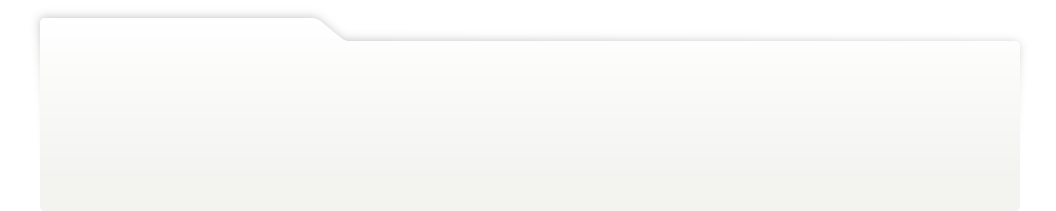
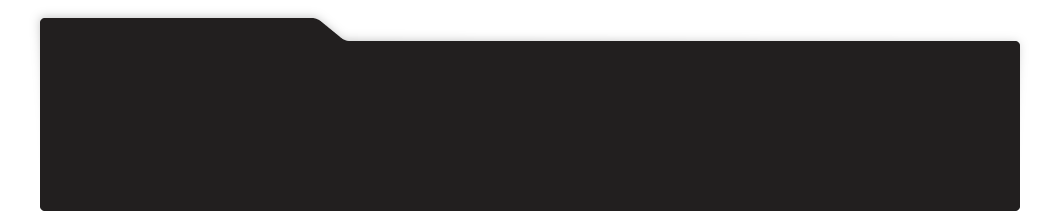
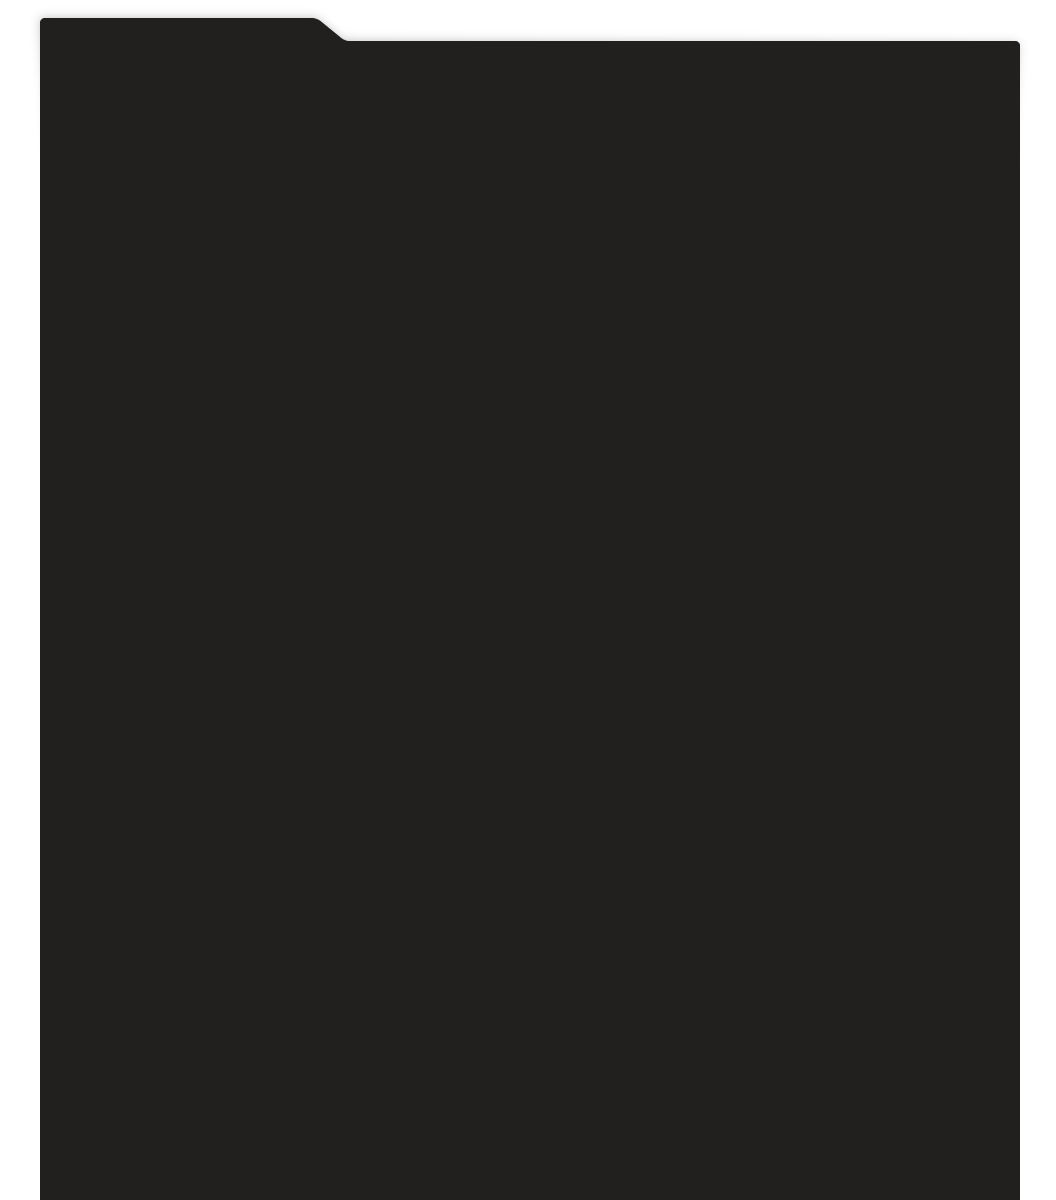
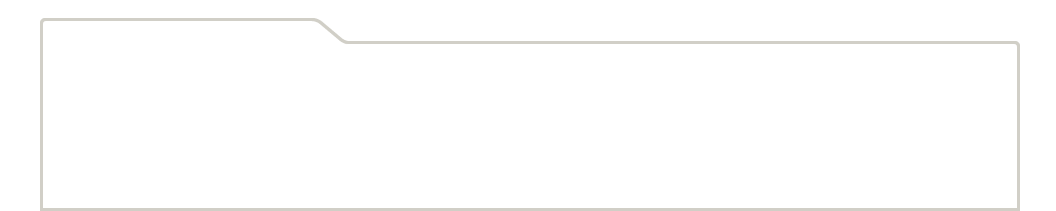
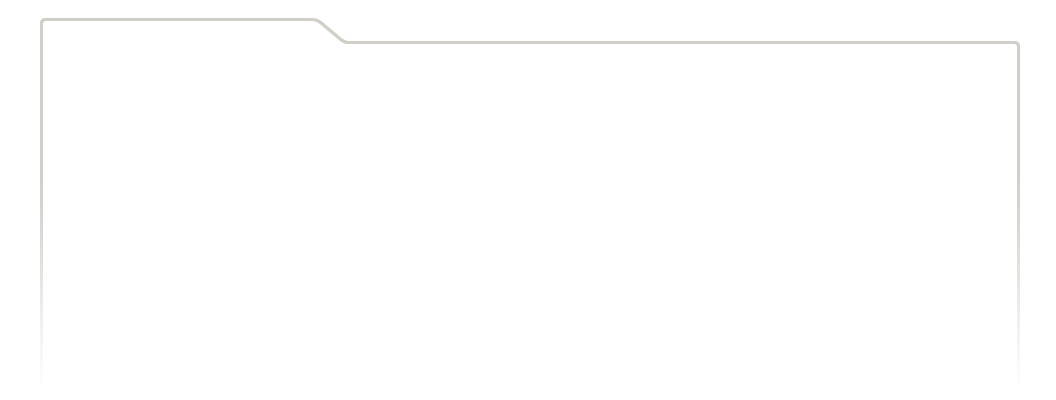
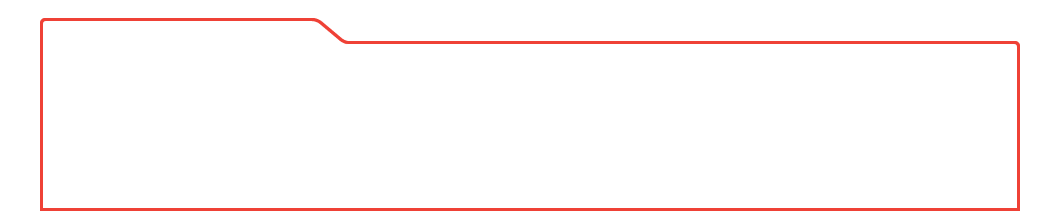
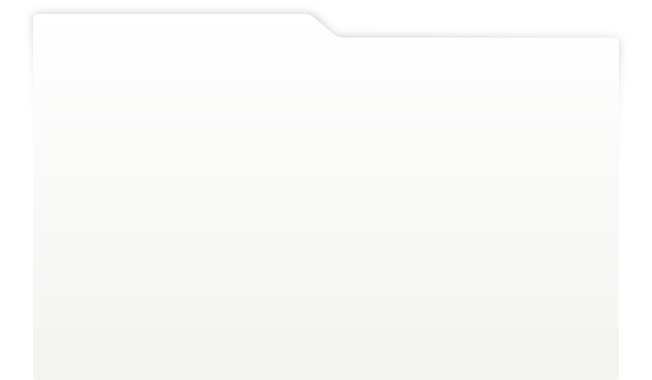
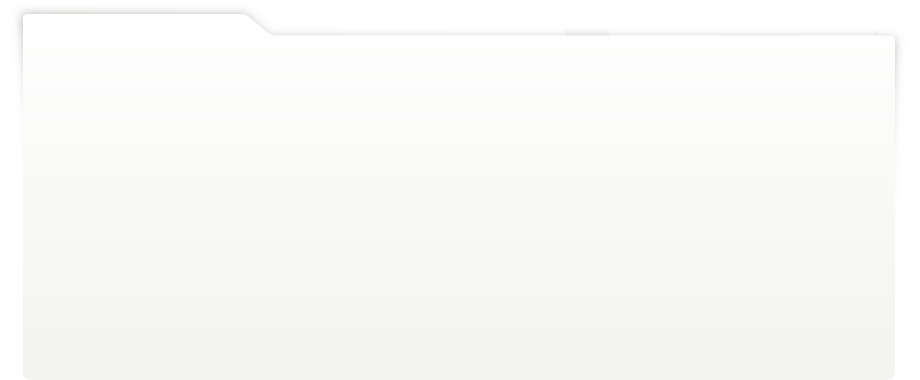
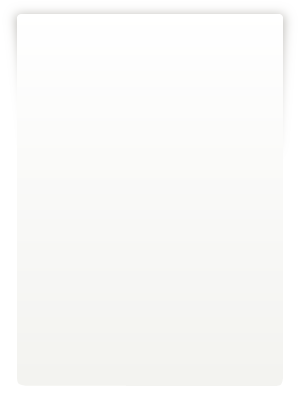
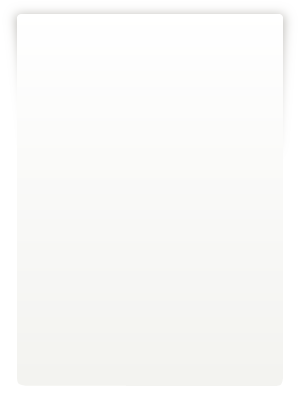
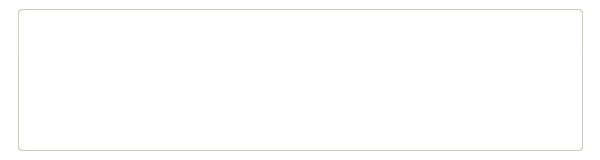
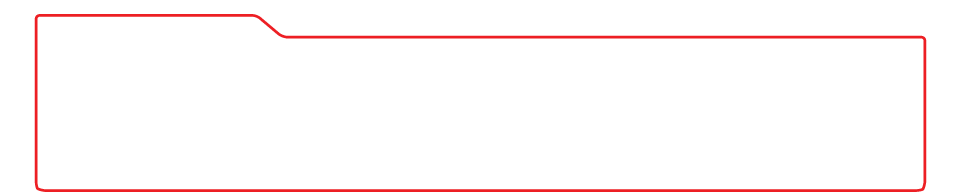
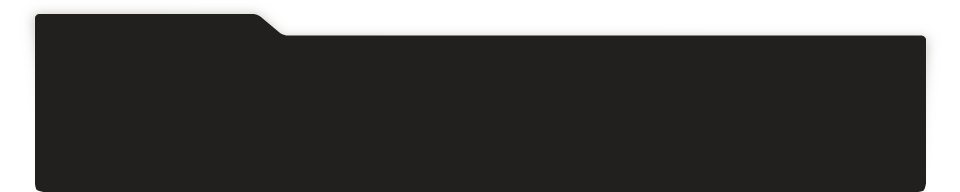
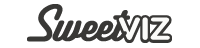
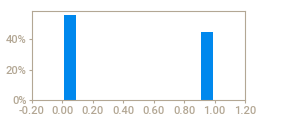
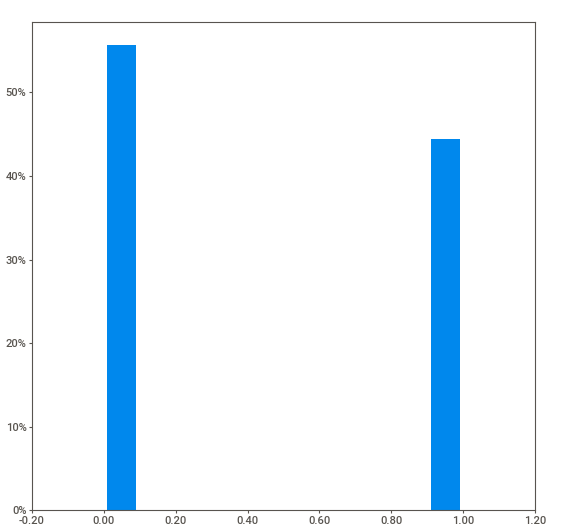
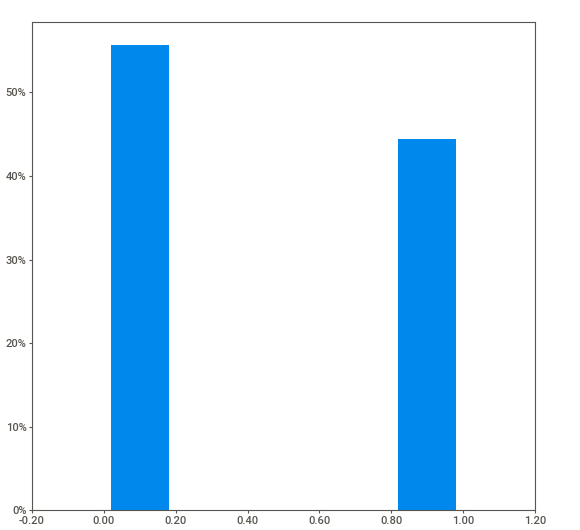
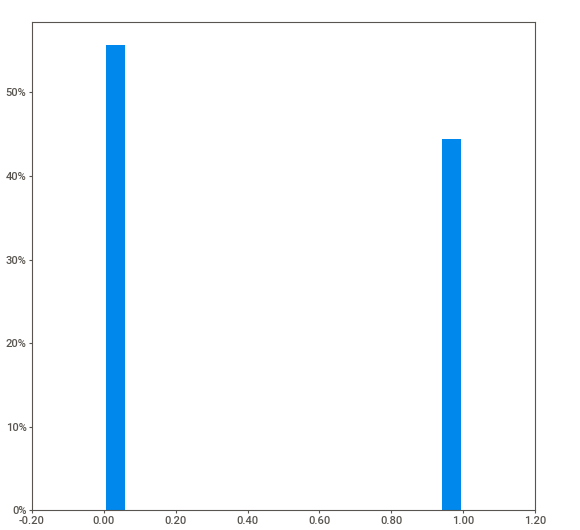
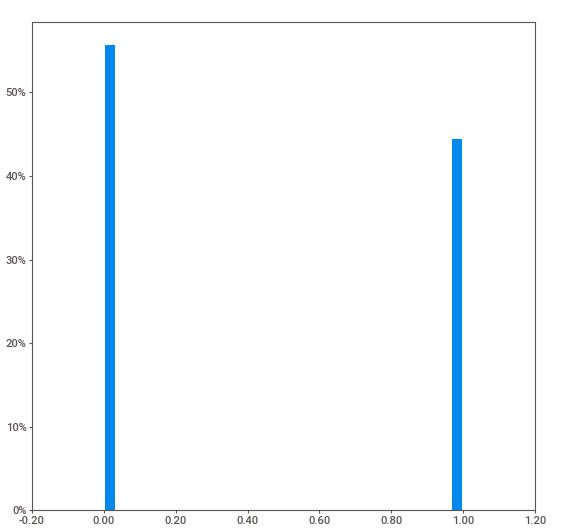
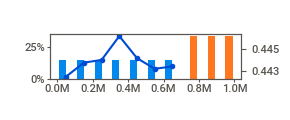
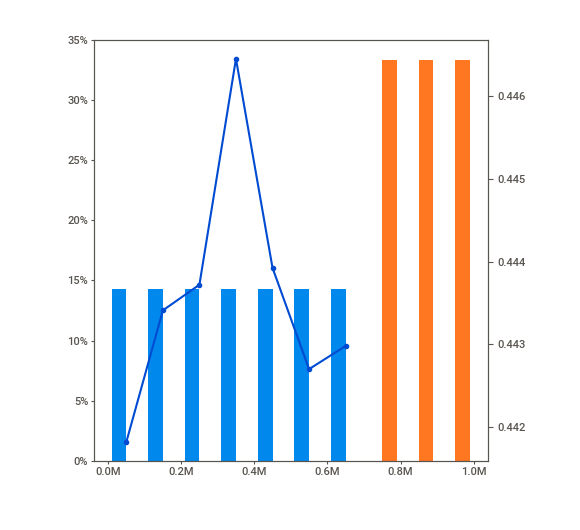
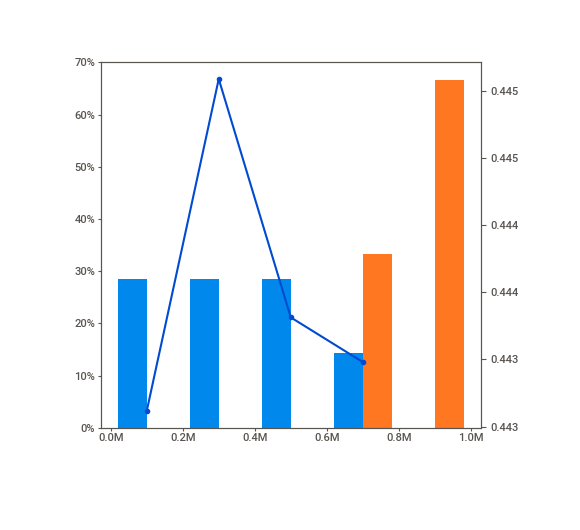
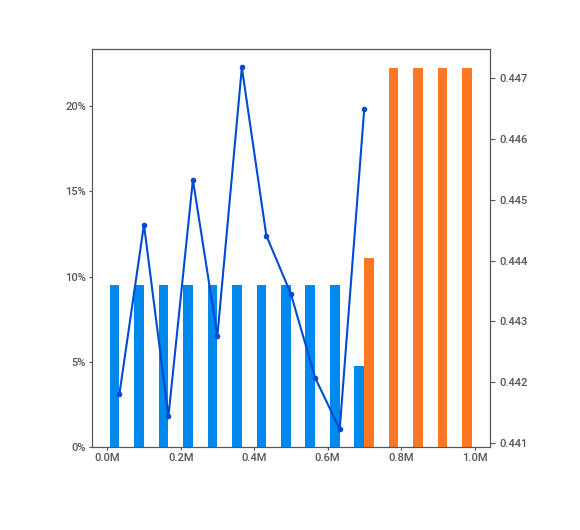
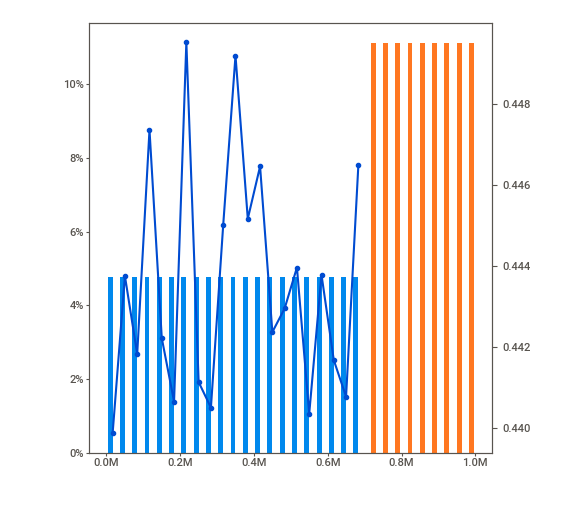
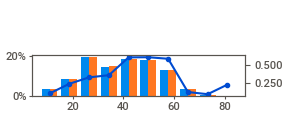
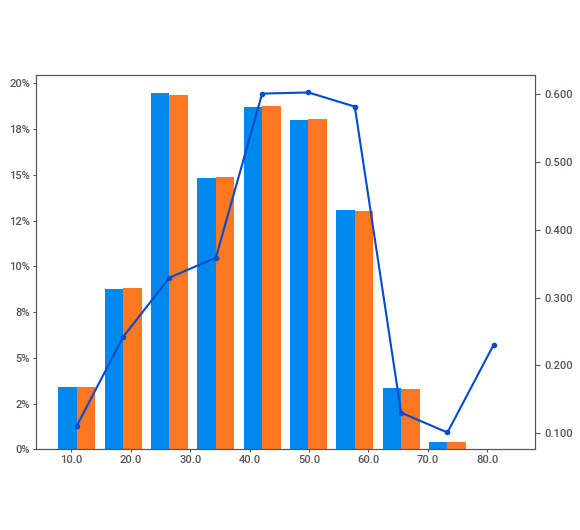
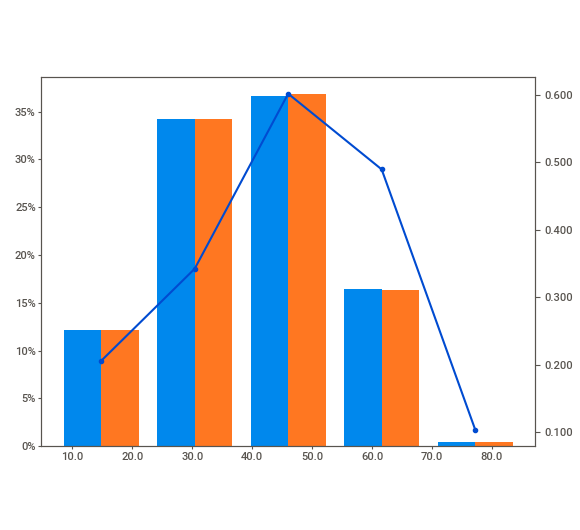
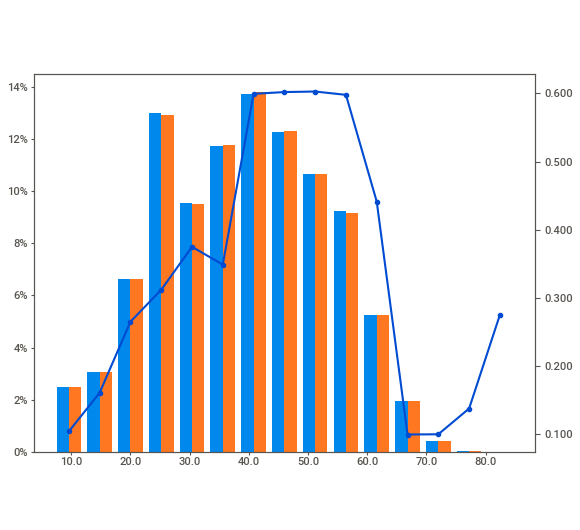
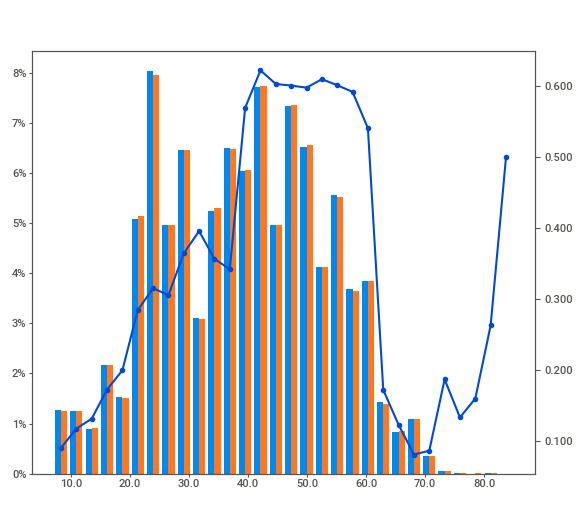
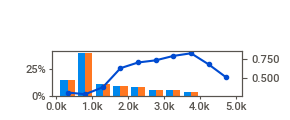
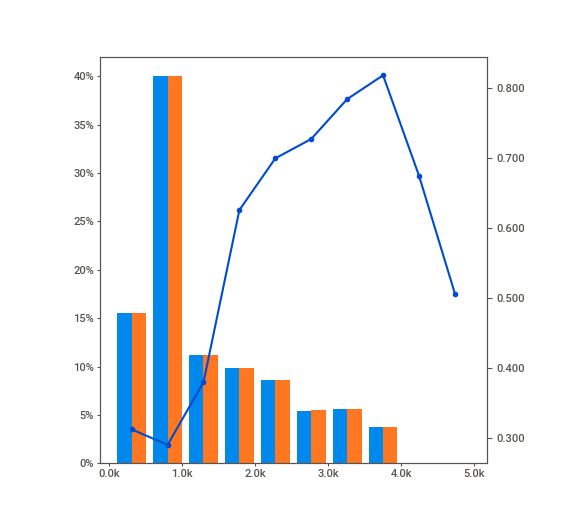
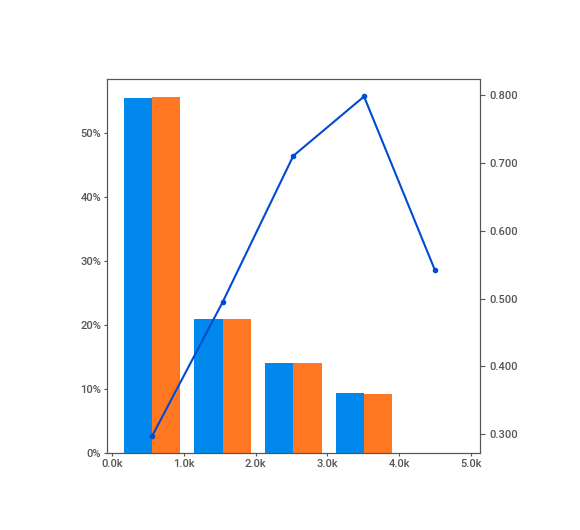
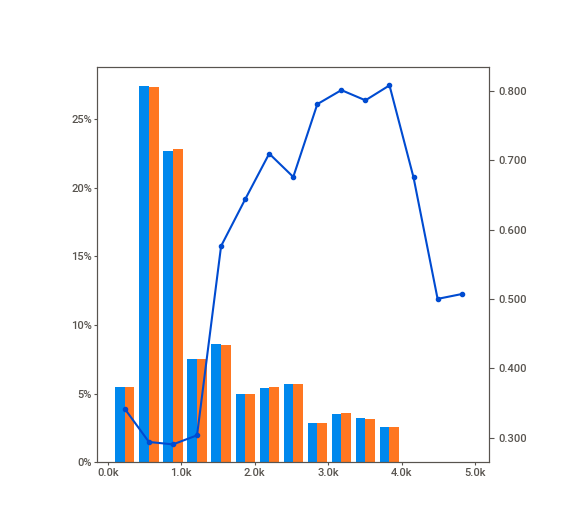
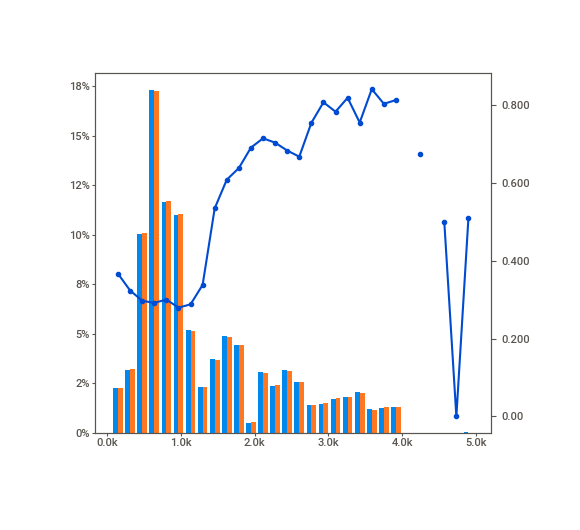
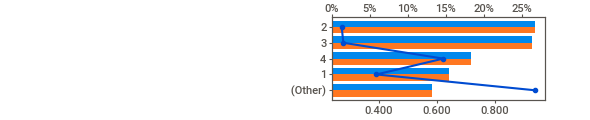
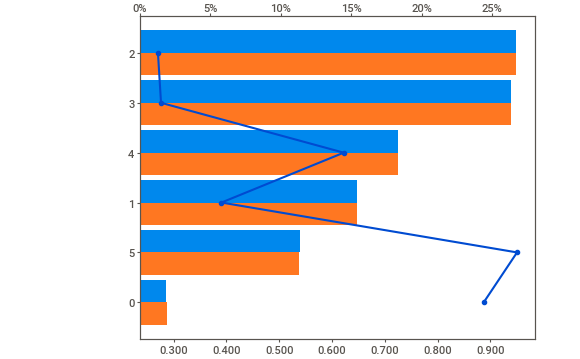
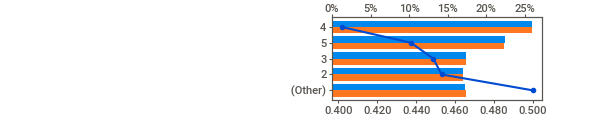
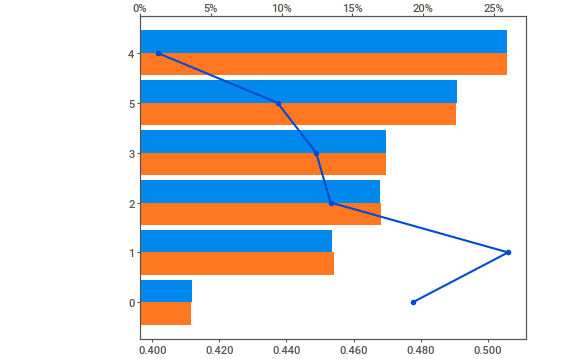
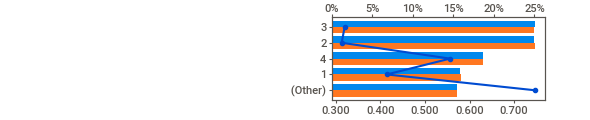
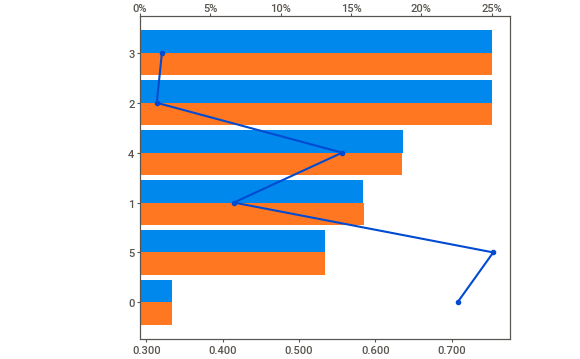
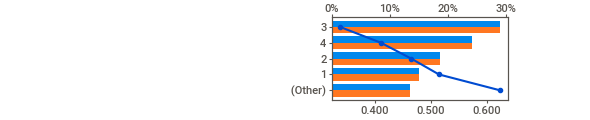
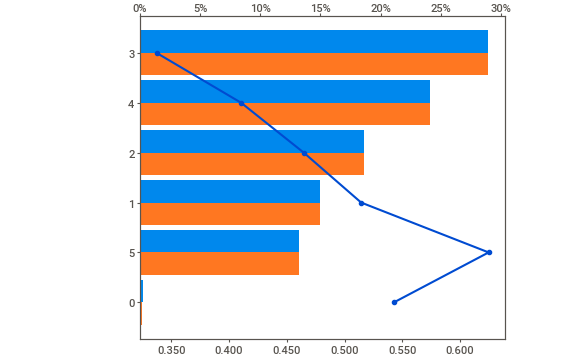
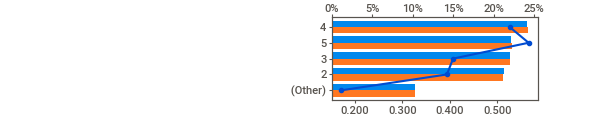
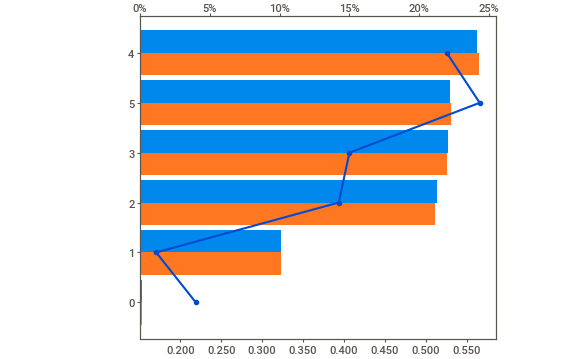
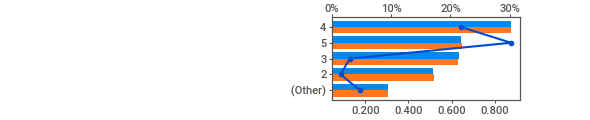
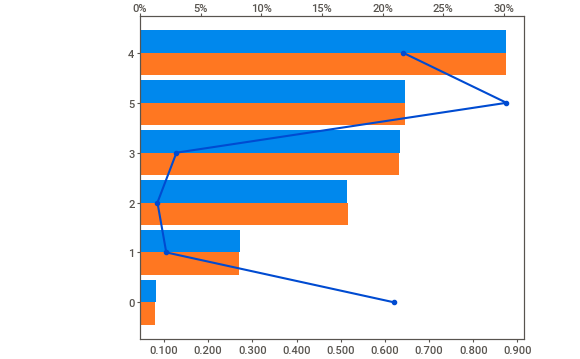
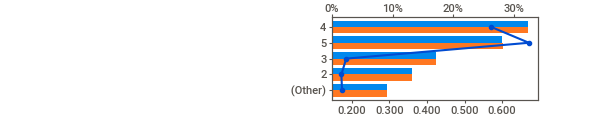
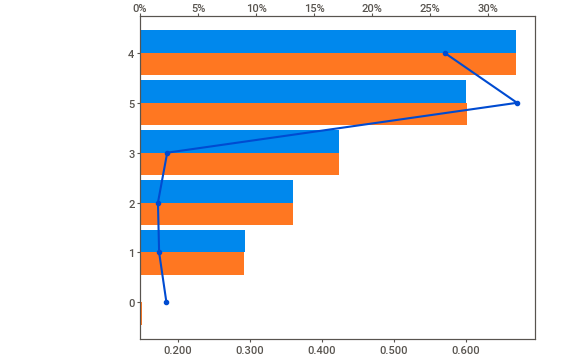
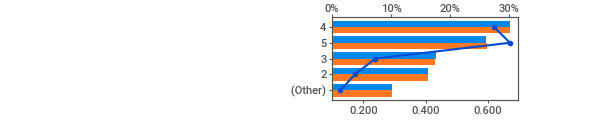
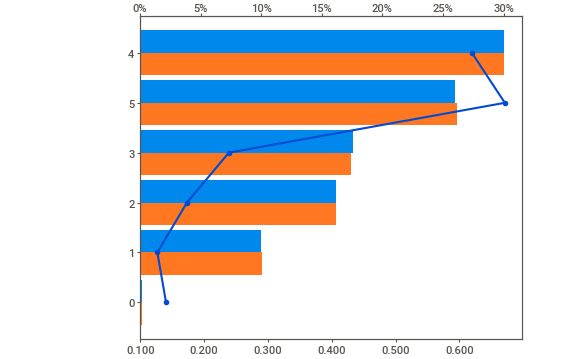
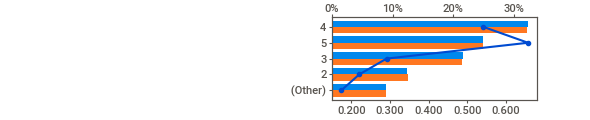
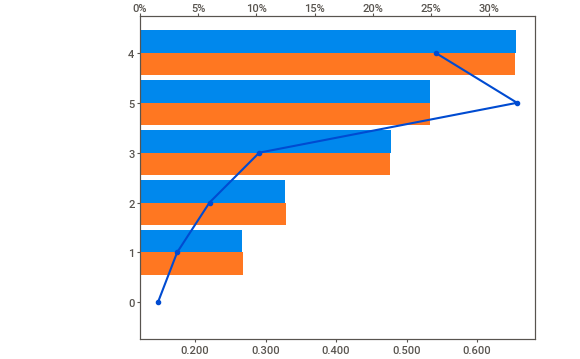
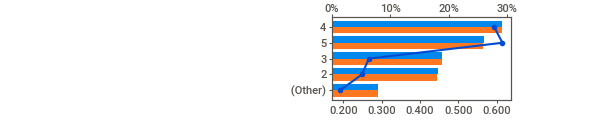
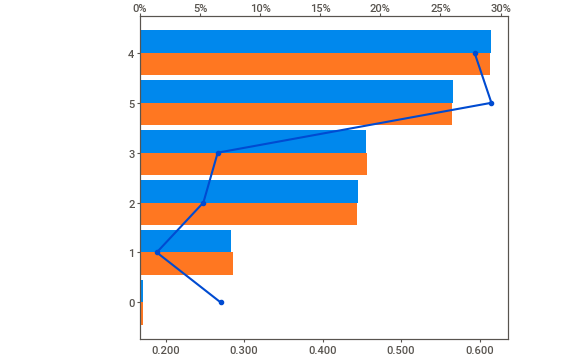
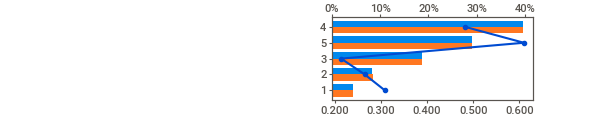
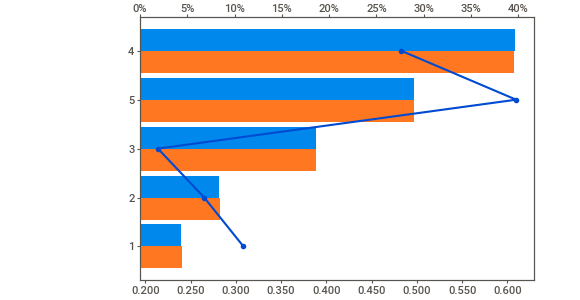
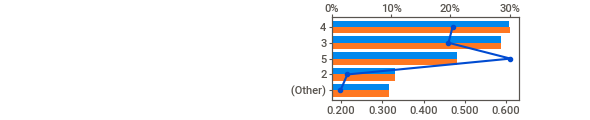
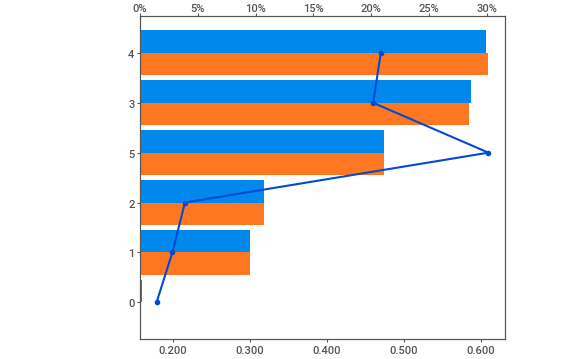
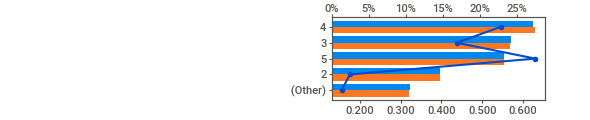
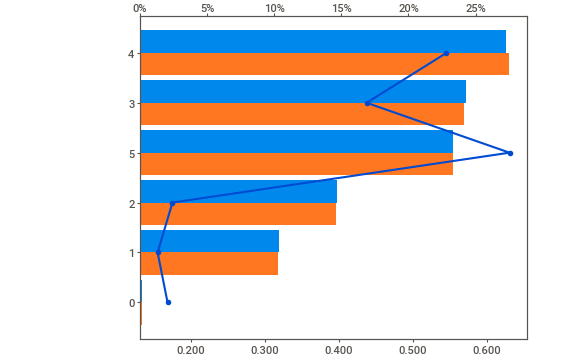
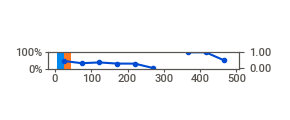
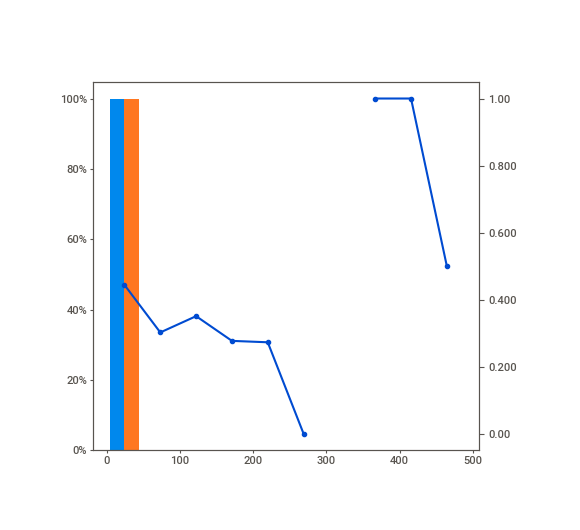
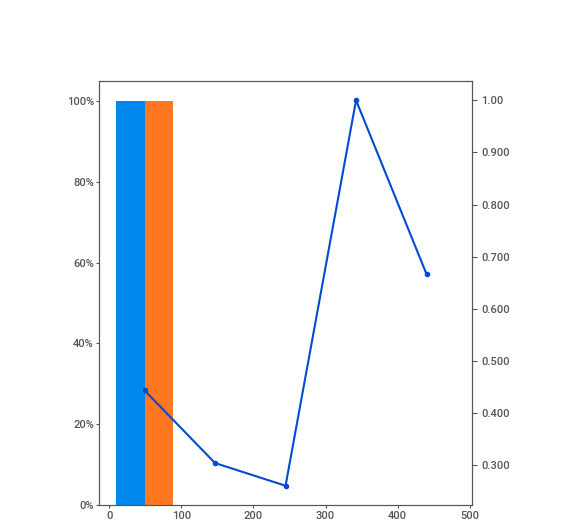
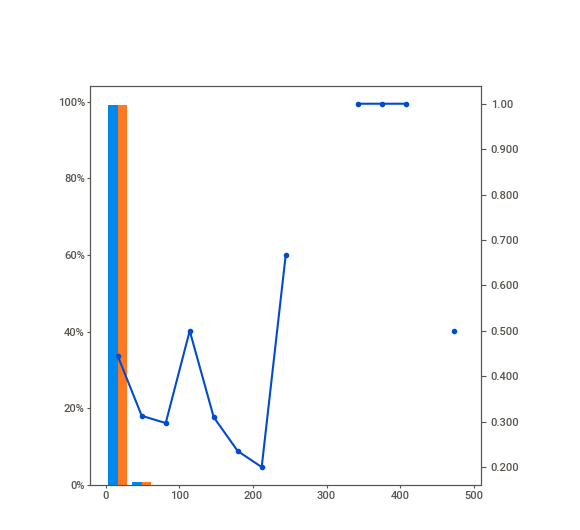
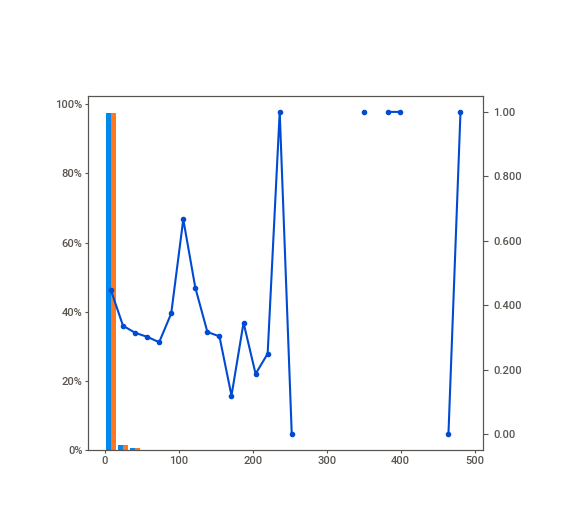
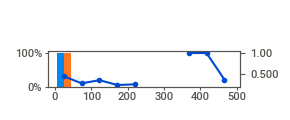
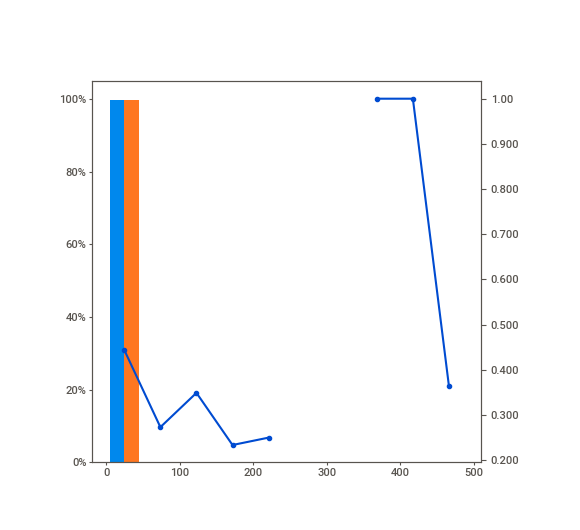
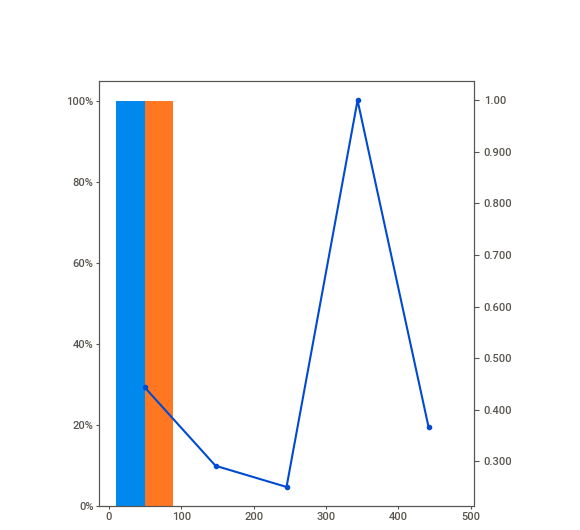
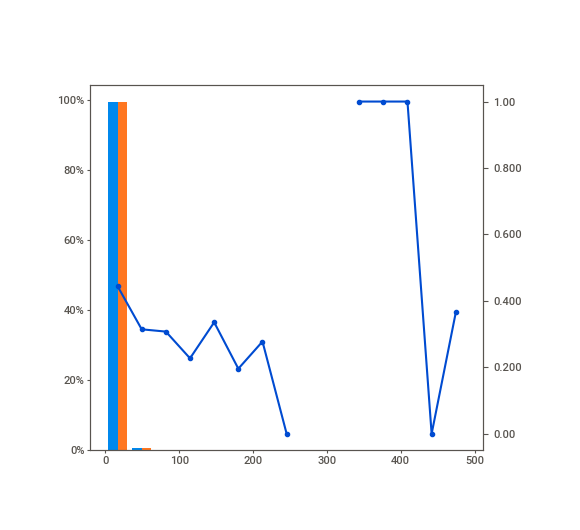
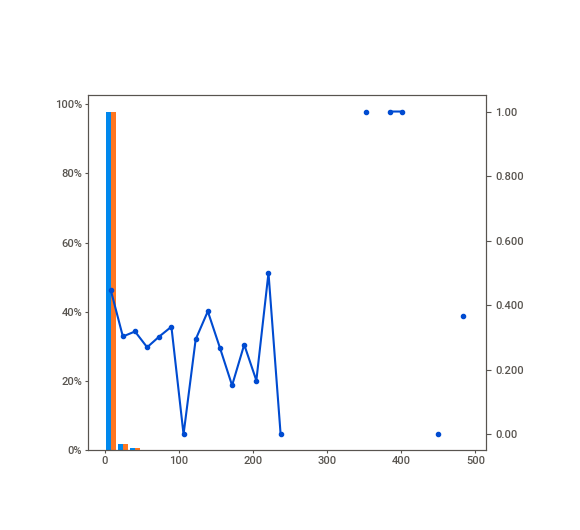
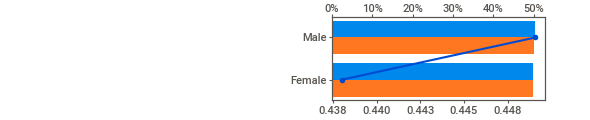
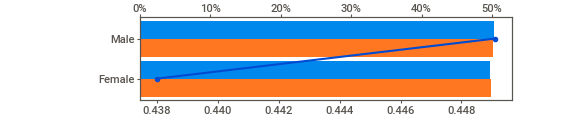
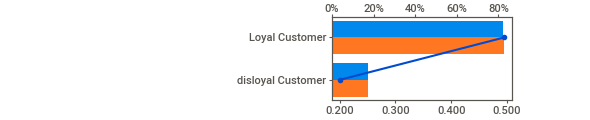
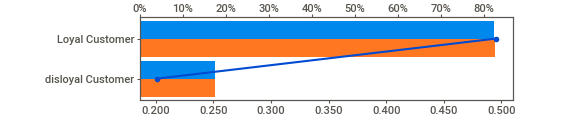
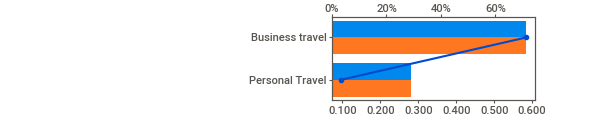
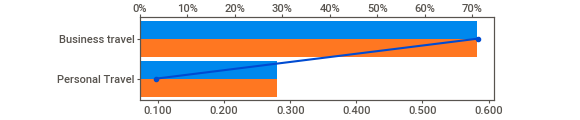
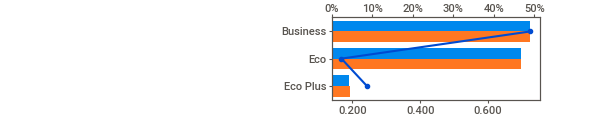
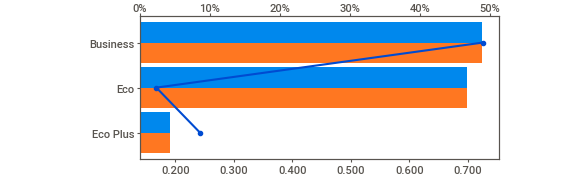
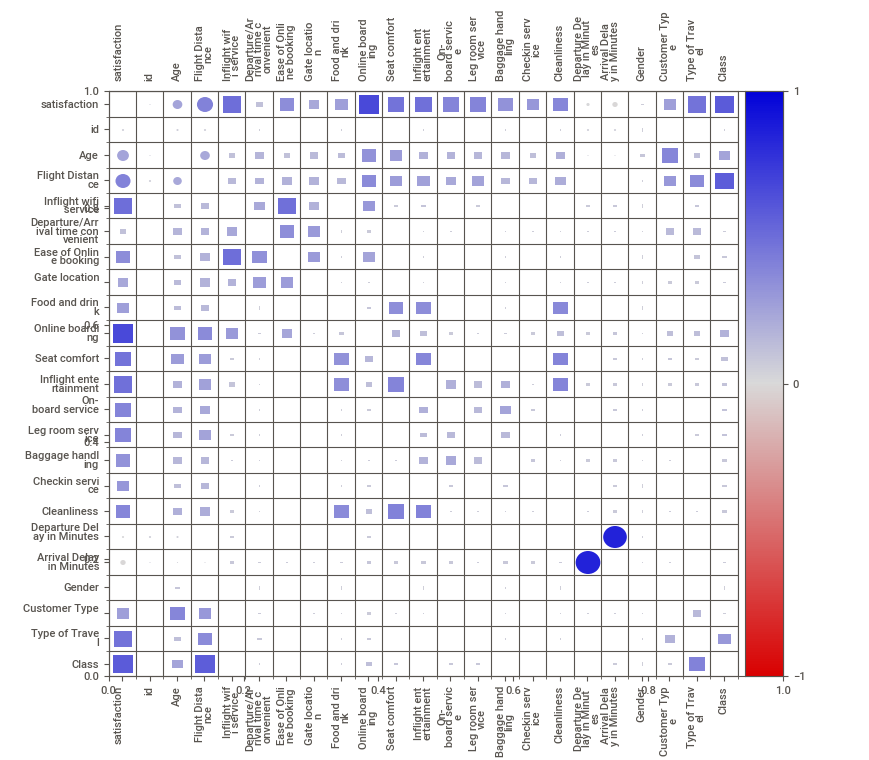
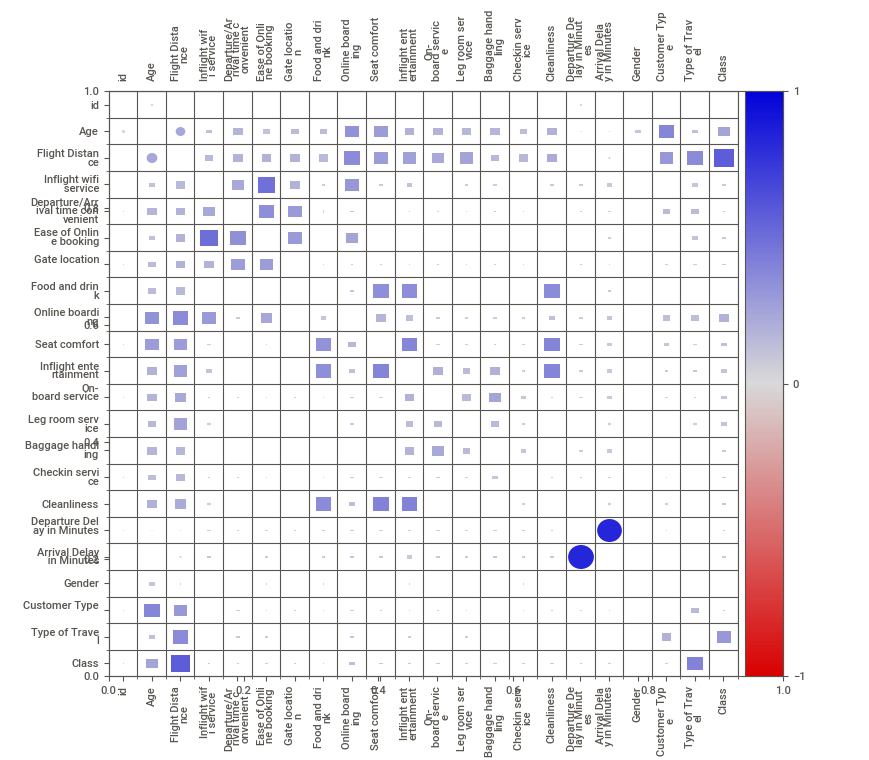

In [6]:
# Convert boolean columns to integer 0/1 for Pandas 2.x Sweetviz compatibility
sweetviz_train_df = training_df.copy()
for col in sweetviz_train_df.select_dtypes(include=['bool']).columns:
    sweetviz_train_df[col] = sweetviz_train_df[col].astype(int)

sweetviz_test_df = test_df.copy()
for col in sweetviz_test_df.select_dtypes(include=['bool']).columns:
    sweetviz_test_df[col] = sweetviz_test_df[col].astype(int)

feat_cfg = sv.FeatureConfig(force_num=[TARGET])

train_test_comparison_report = sv.compare(
    [sweetviz_train_df, "Training Data"],
    [sweetviz_test_df, "Test Data"],
    target_feat=TARGET,
    feat_cfg=feat_cfg
)

# Save HTML report file for full tab browsing
train_test_comparison_report.show_html(
    filepath="sweetviz_train_test.html",
    open_browser=False
)

# Render in notebook
train_test_comparison_report.show_notebook(
    w="100%",
    h=1000,
    scale=0.85
)

### Train vs Test Drift Analysis Insights

Based on Kolmogorov-Smirnov (KS) tests comparing numerical distributions between train (699,635 rows) and test (299,844 rows):
* **Zero Significant Drift**: All features exhibit virtually identical distributions between train and test splits.
* **Missing Values**: `Arrival Delay in Minutes` has 292 missing values in train and 130 missing values in test.
* **Implication**: Test data is drawn from the same synthetic distribution. Local 5-fold cross-validation will accurately mirror Kaggle leaderboard performance.

### Standalone Training Profile Report

*(Saved locally as [sweetviz_training_profile.html](sweetviz_training_profile.html))*

                                             |                                                                …

Report sweetviz_training_profile.html was generated.



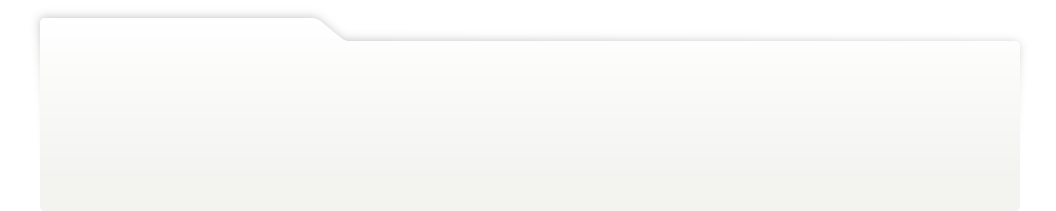
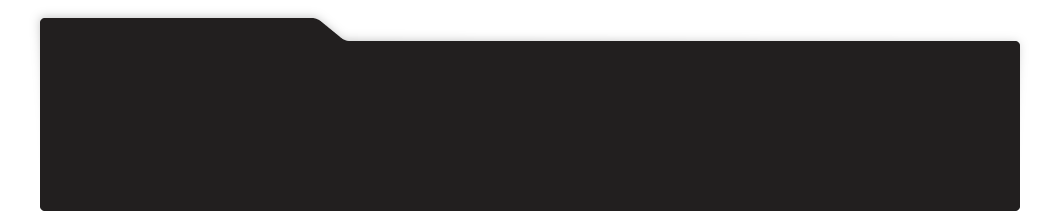
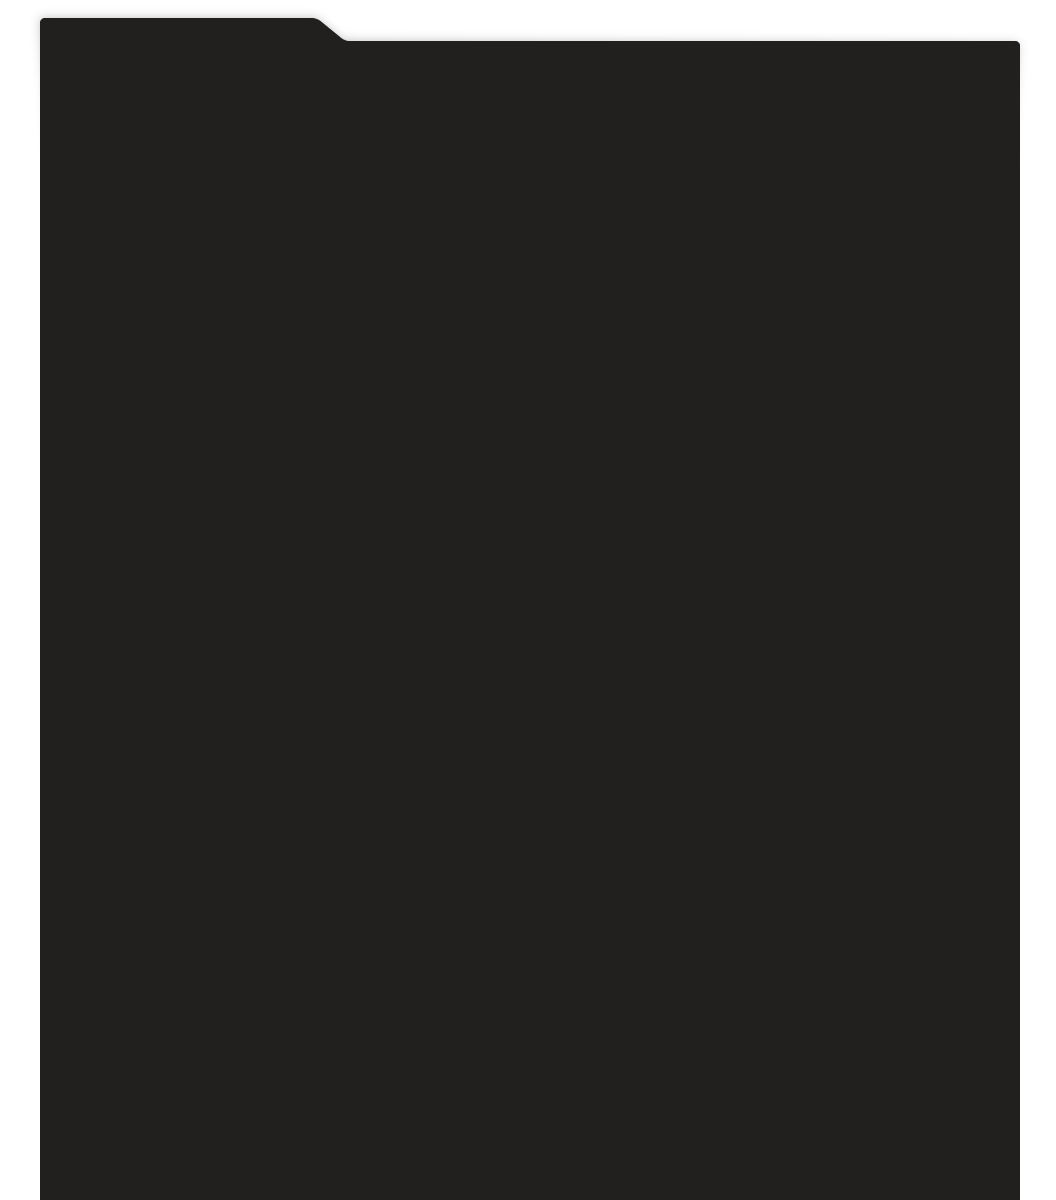
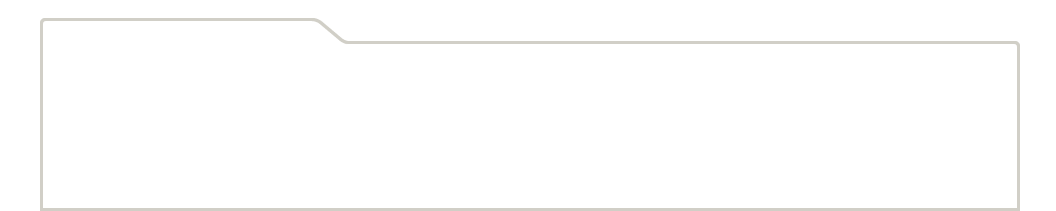
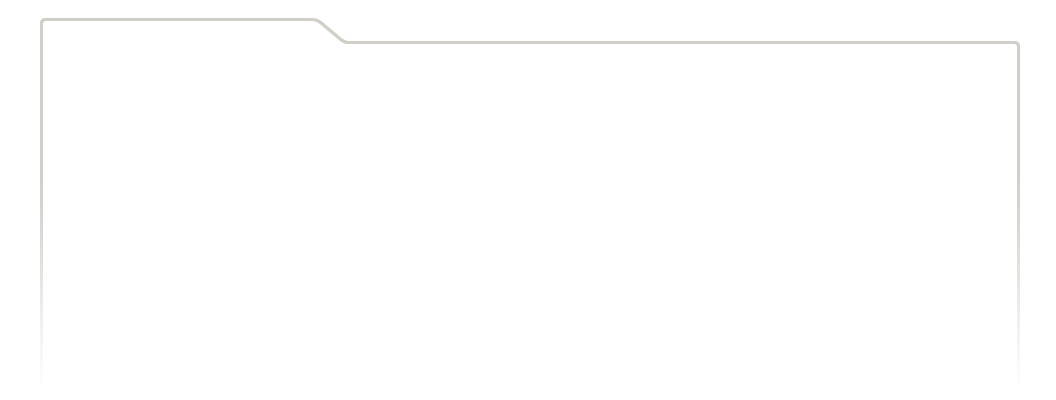
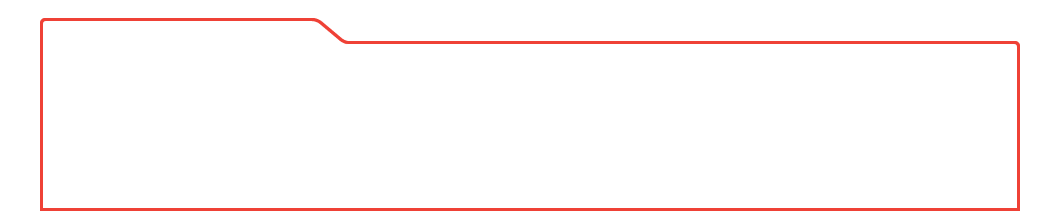
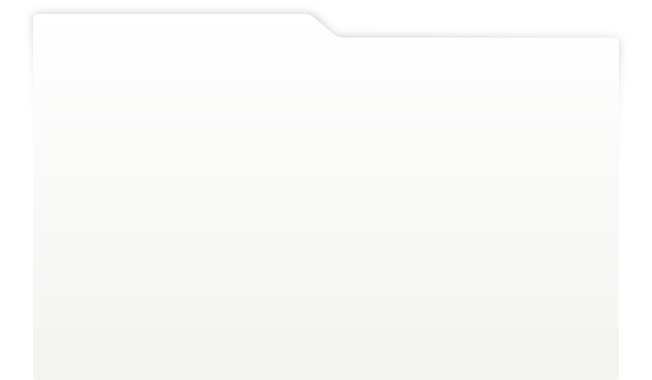
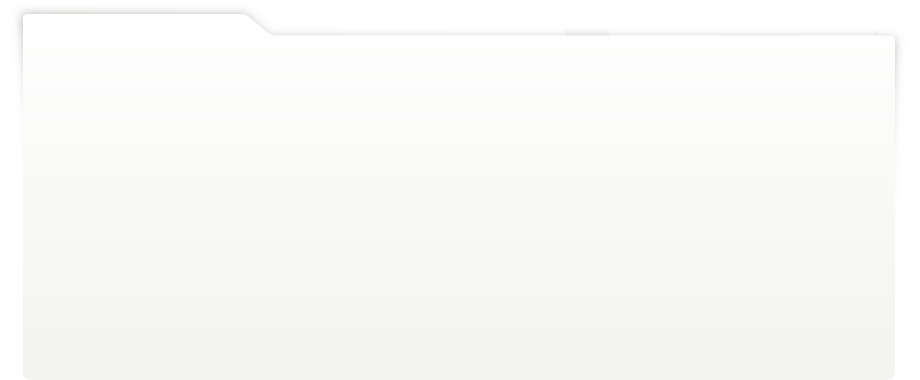
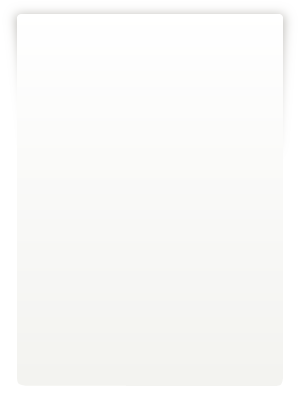
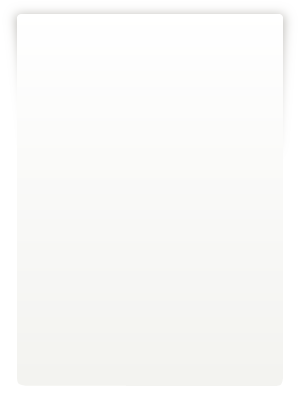
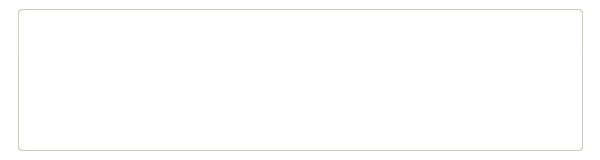
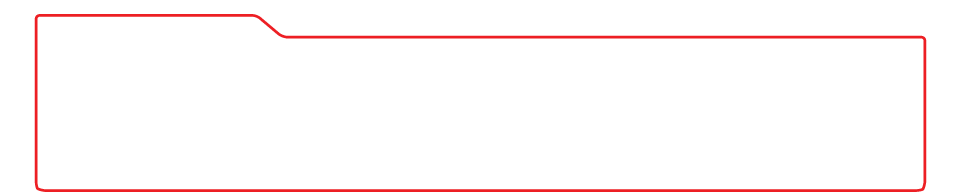
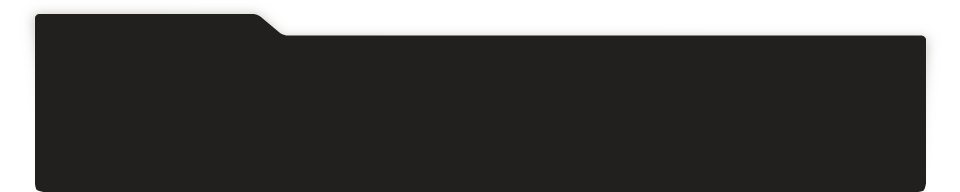
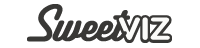
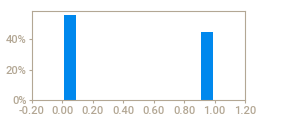
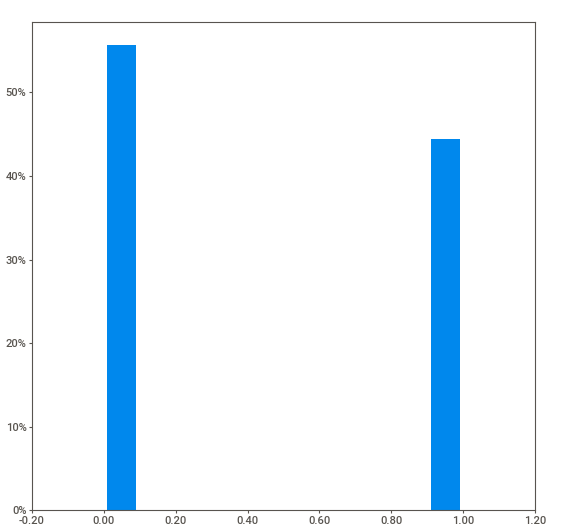
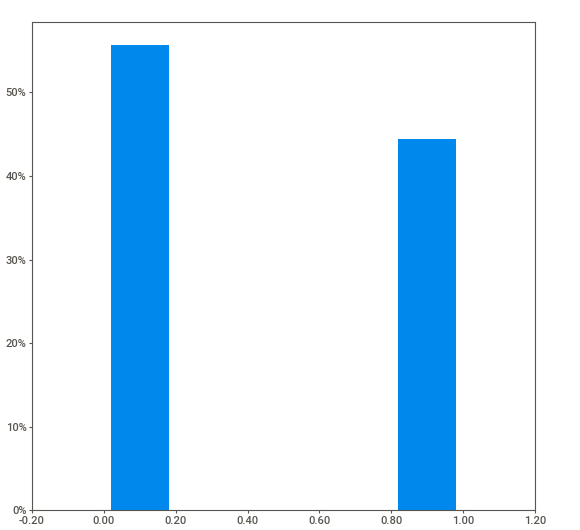
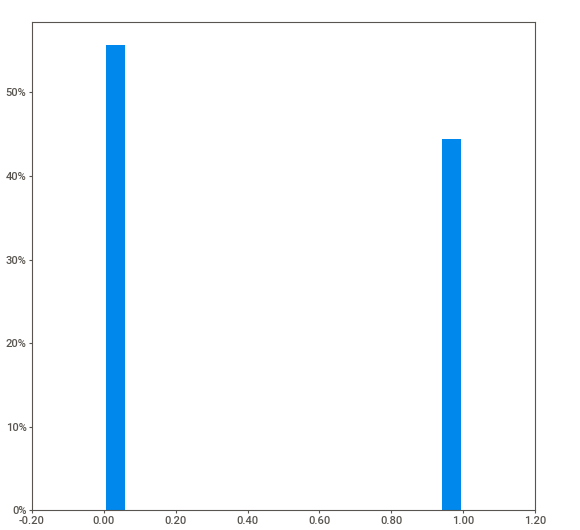
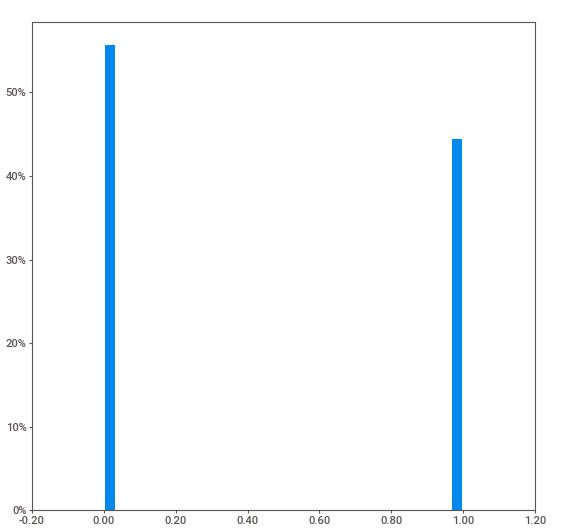
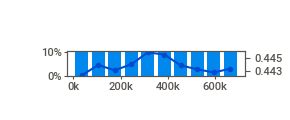
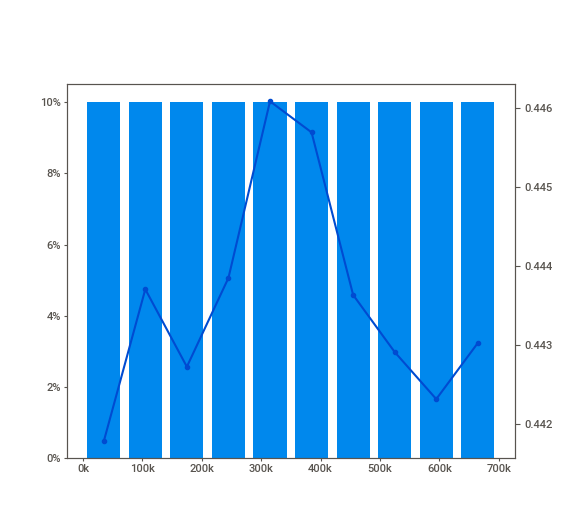
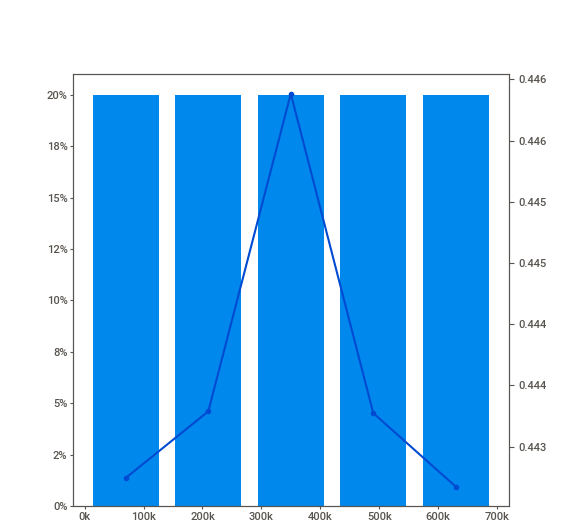
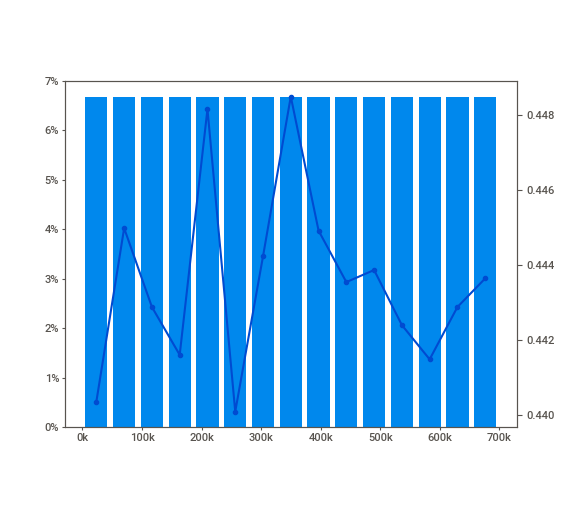
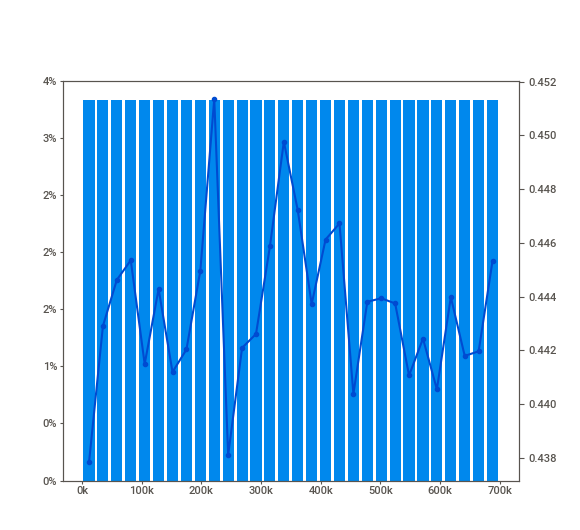
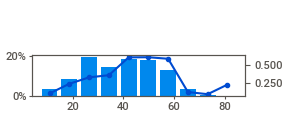
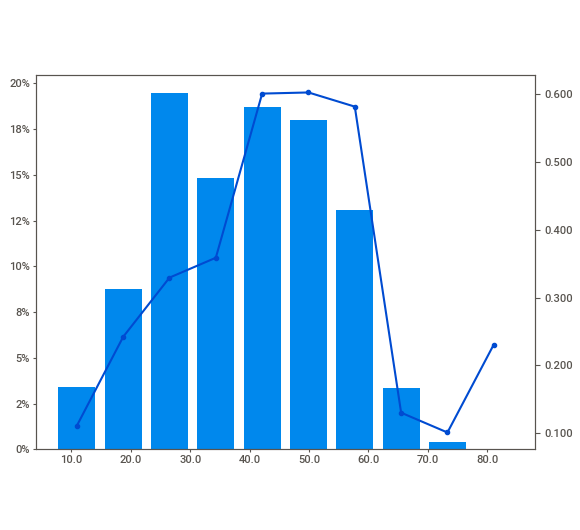
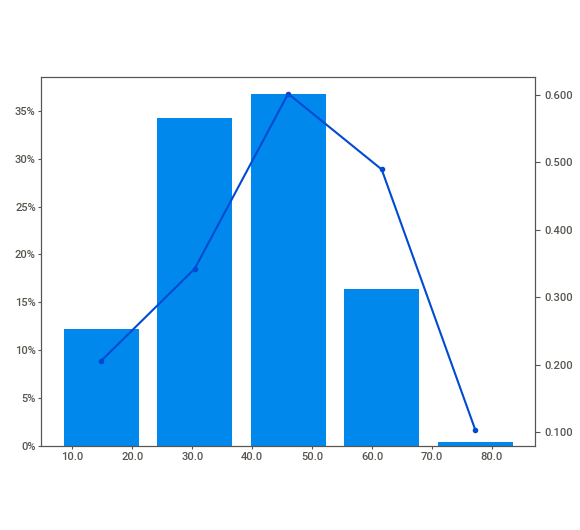
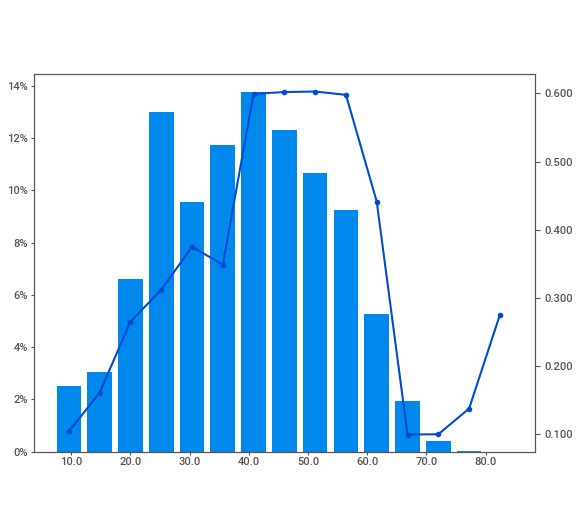
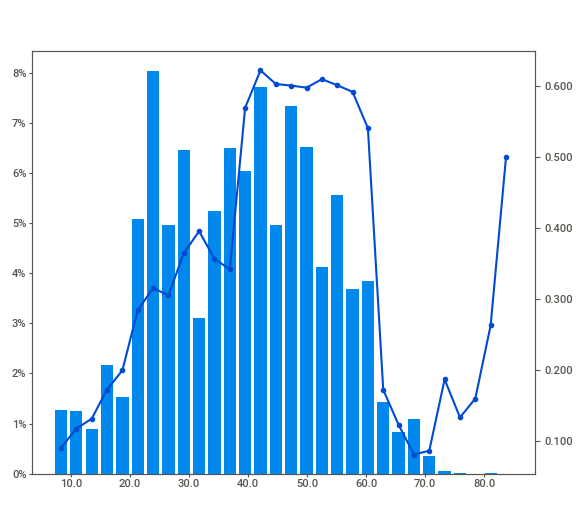
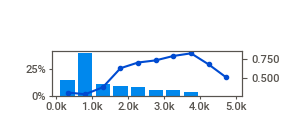
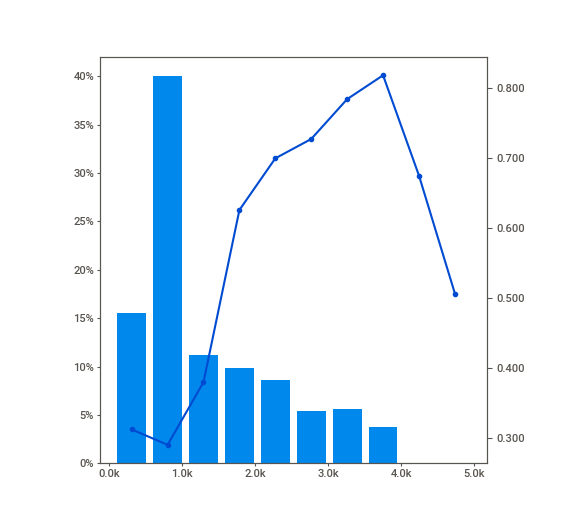
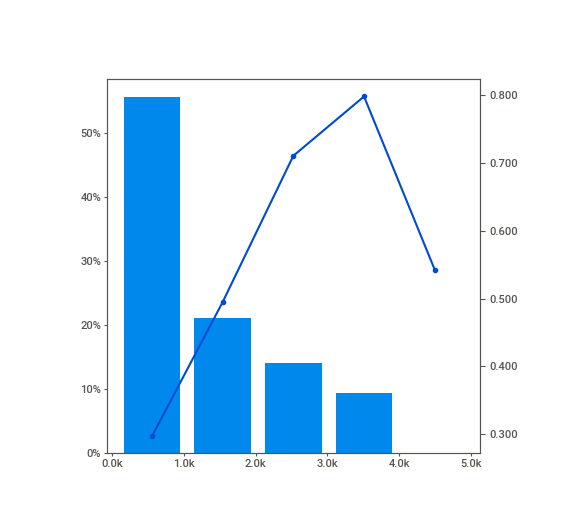
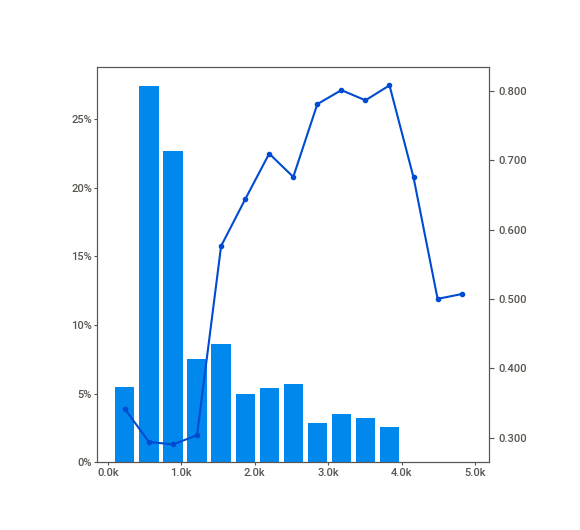
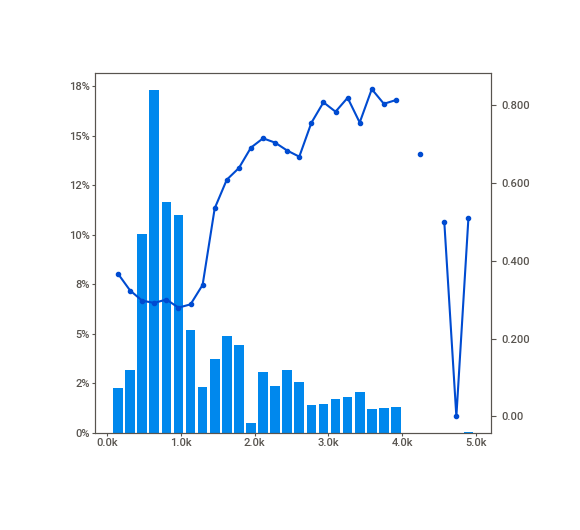
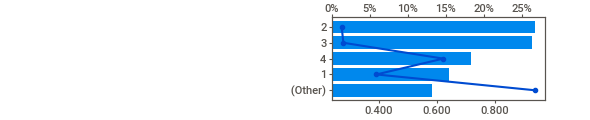
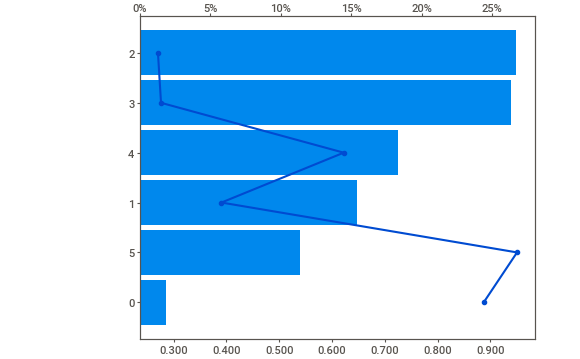
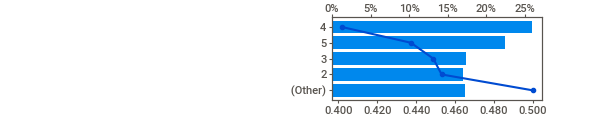
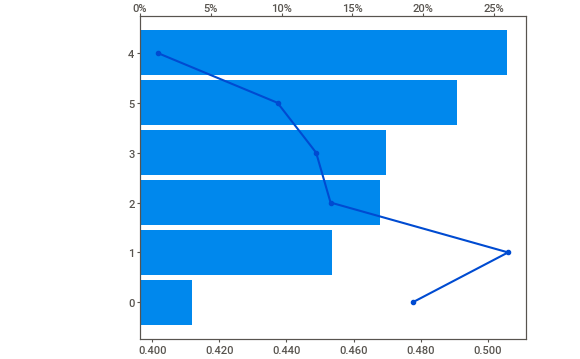
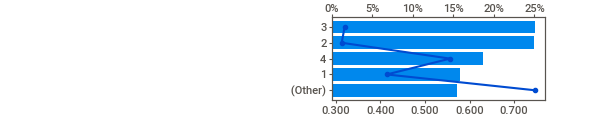
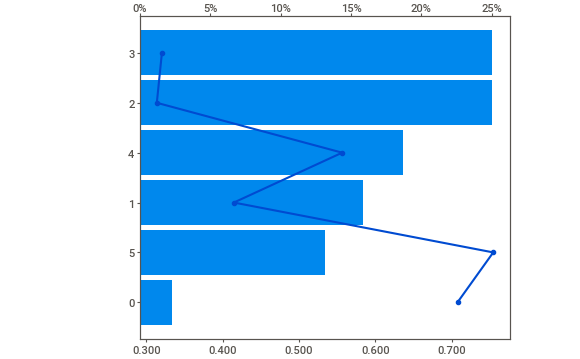
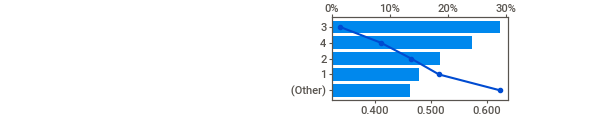
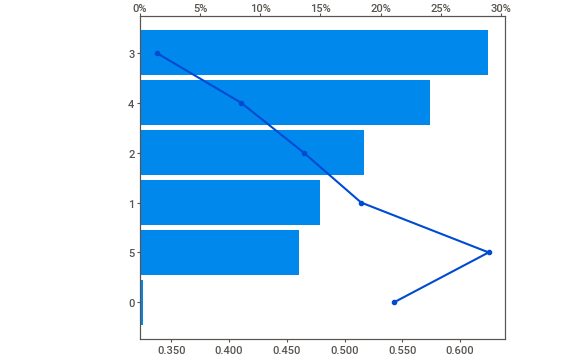
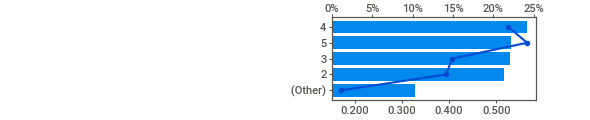
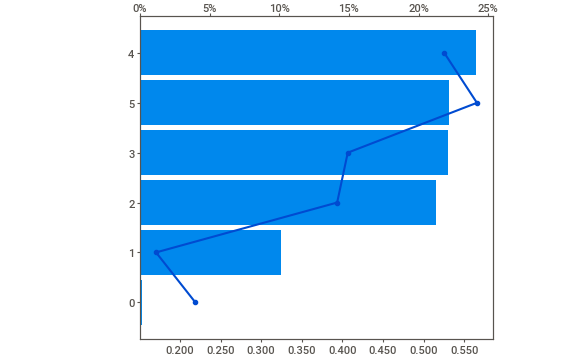
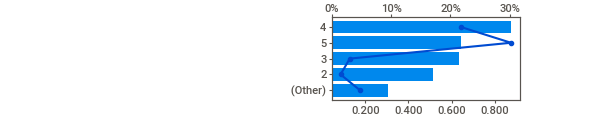
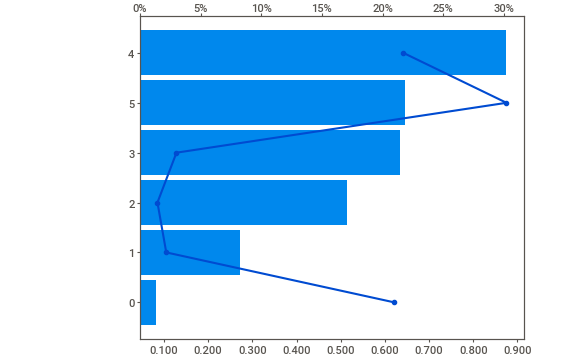
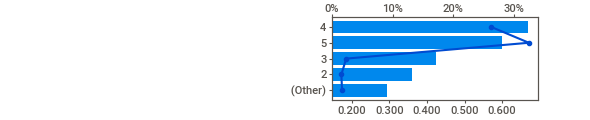
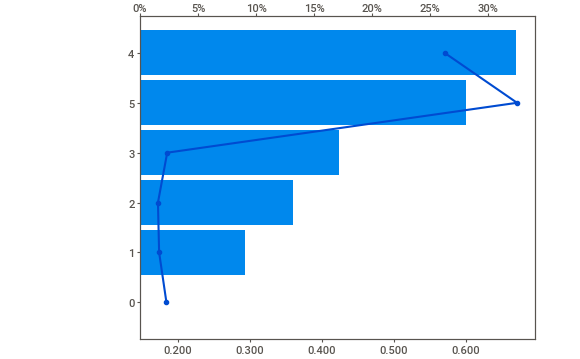
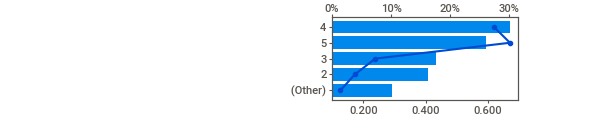
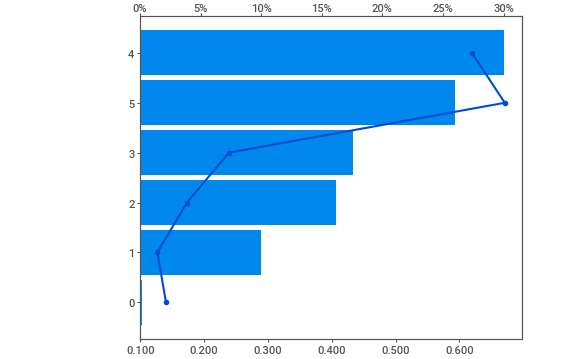
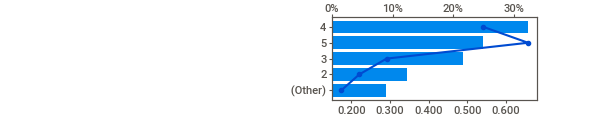
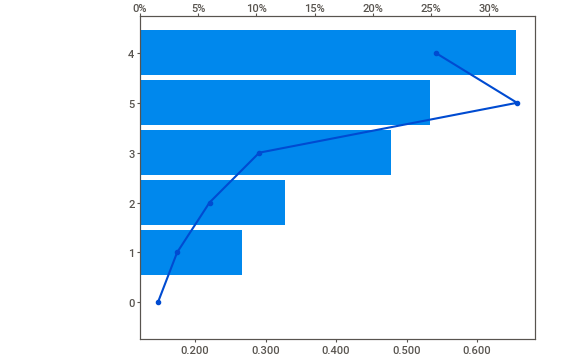
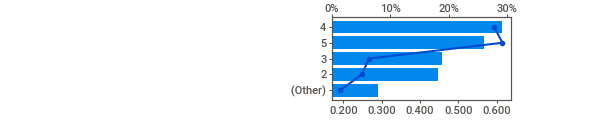
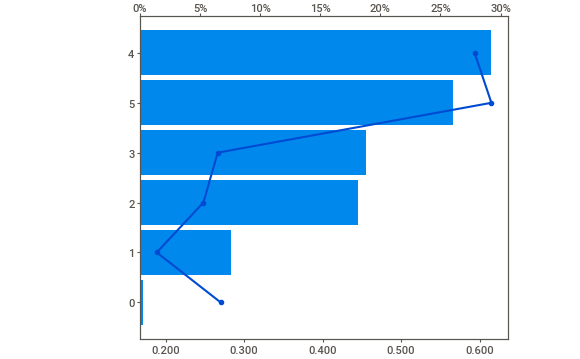
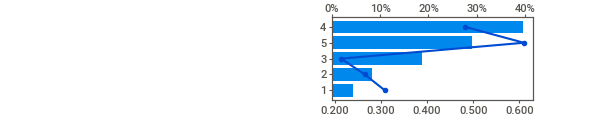
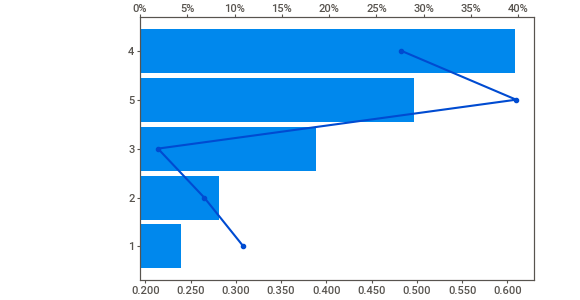
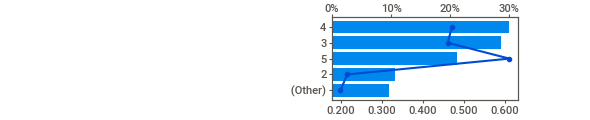
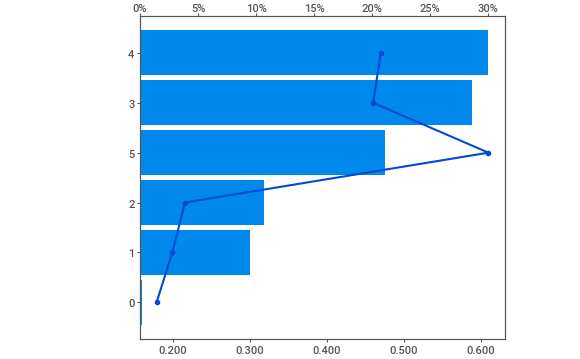
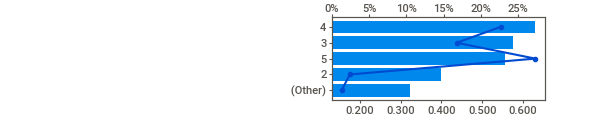
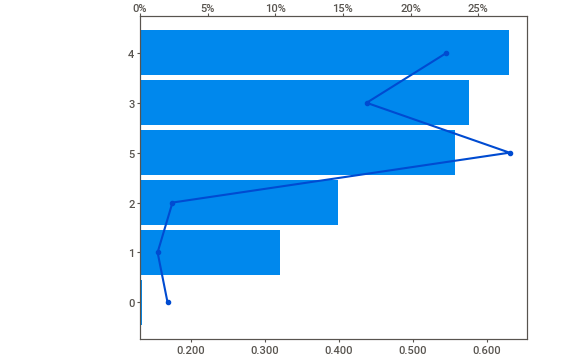
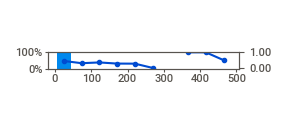
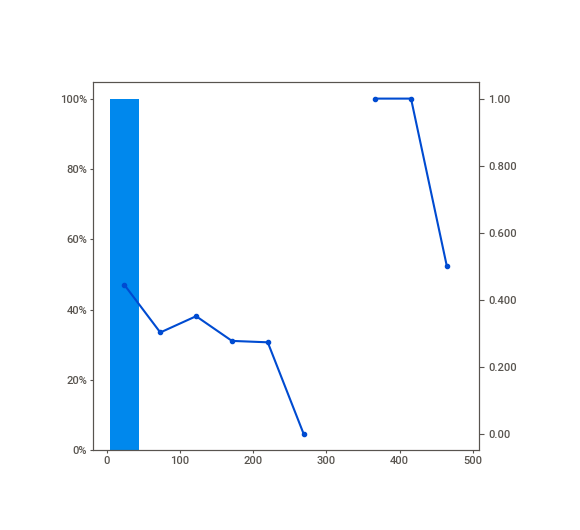
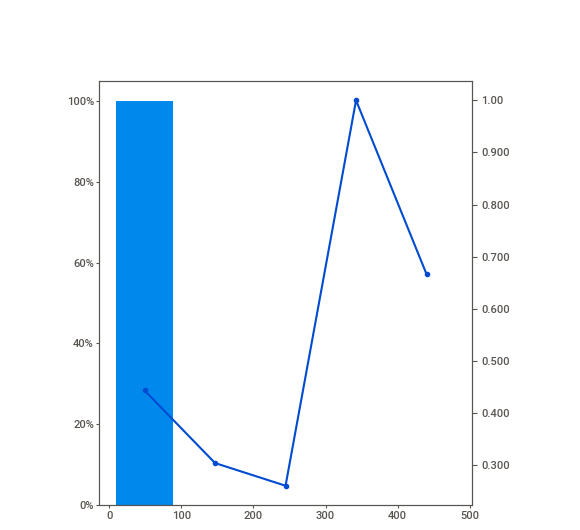
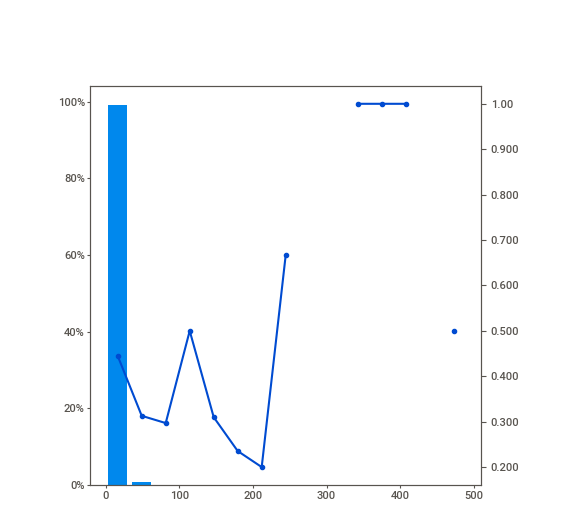
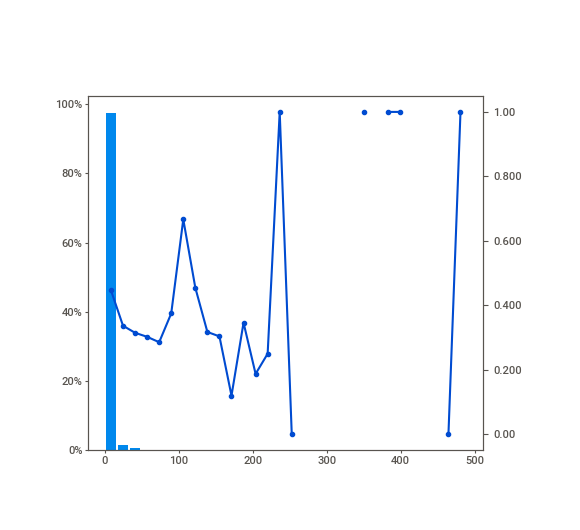
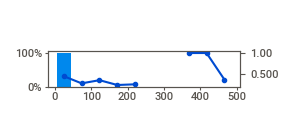
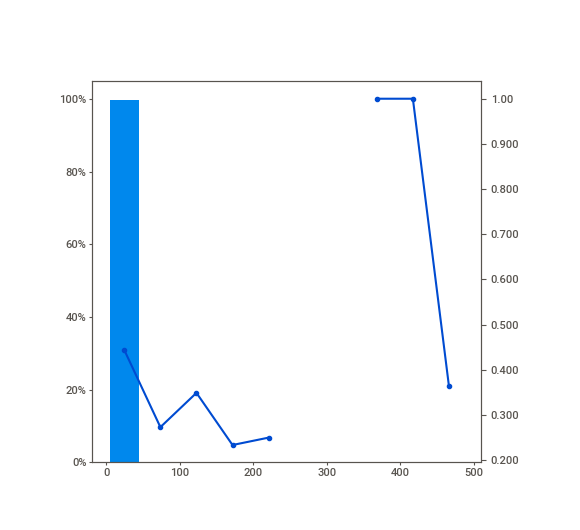
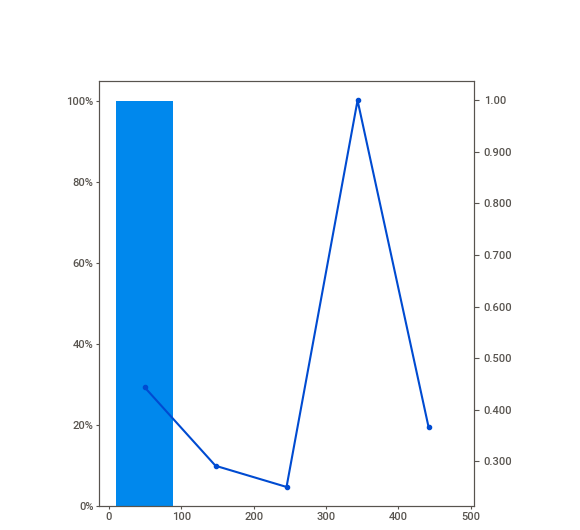
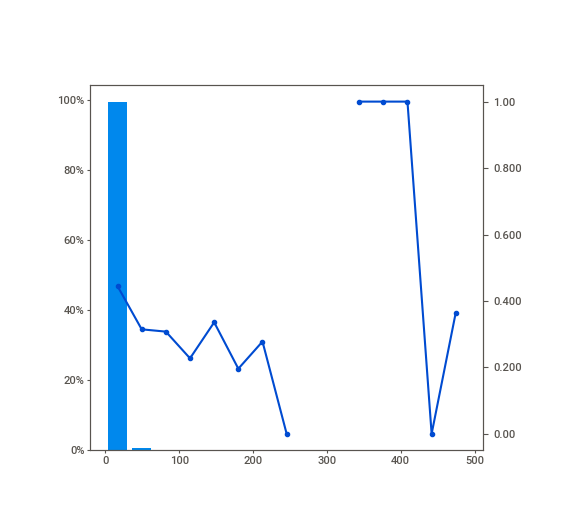
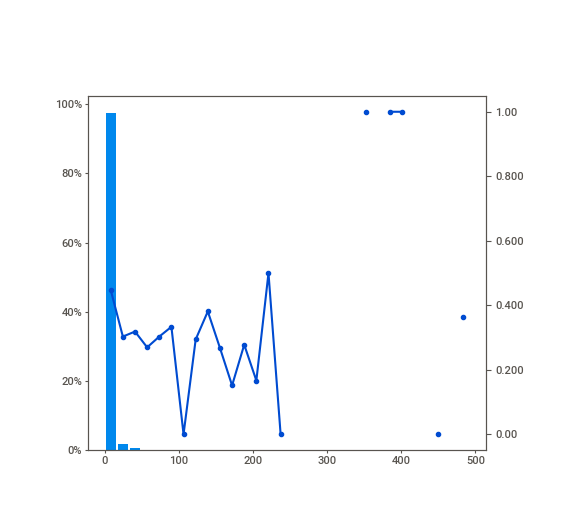
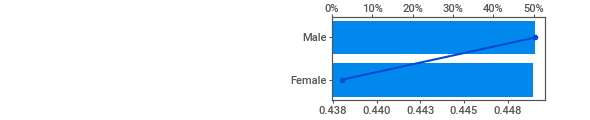
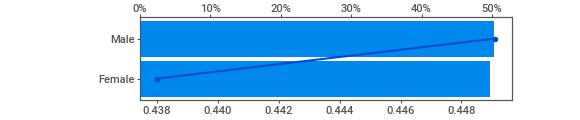
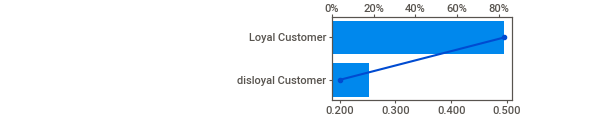
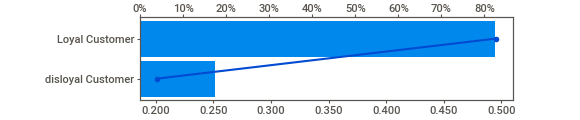
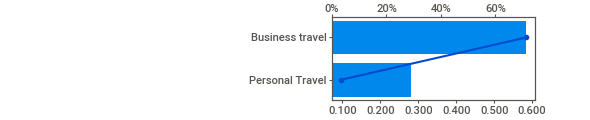
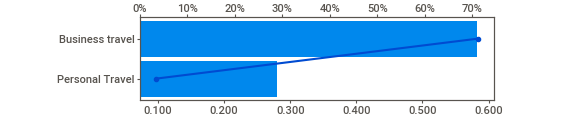
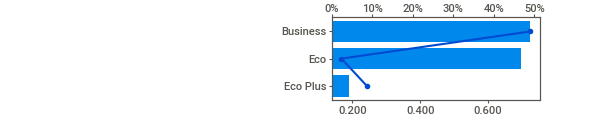
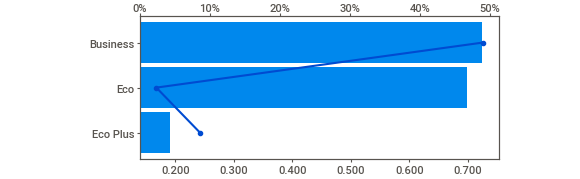
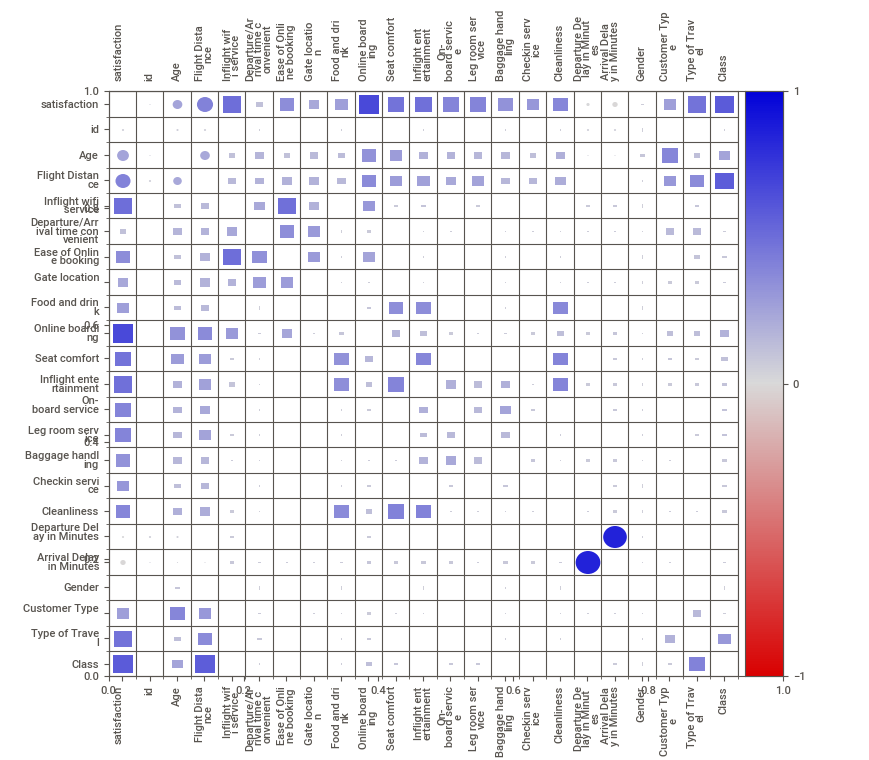
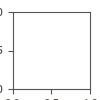

In [7]:
training_report = sv.analyze(
    [sweetviz_train_df, "Training Data"],
    target_feat=TARGET,
    feat_cfg=feat_cfg
)

# Save HTML report file
training_report.show_html(
    filepath="sweetviz_training_profile.html",
    open_browser=False
)

# Render in notebook
training_report.show_notebook(
    w="100%",
    h=1000,
    scale=0.85
)

### Intra-class Comparison (Satisfied vs. Dissatisfied/Neutral)

Compare satisfied passengers (`satisfaction == 1`) versus dissatisfied/neutral passengers (`satisfaction == 0`).

                                             |                                                                …

Report sweetviz_satisfied_intra.html was generated.



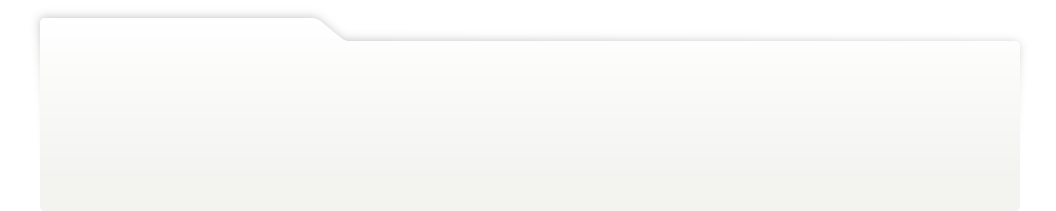
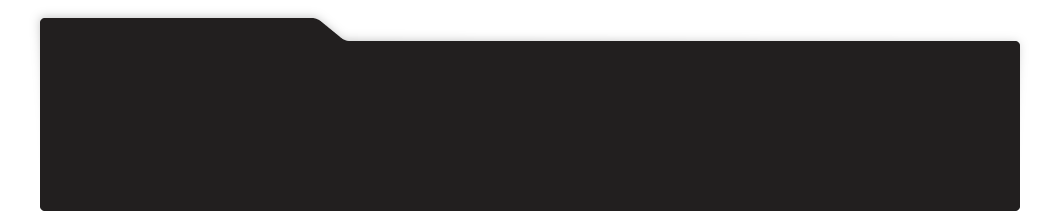
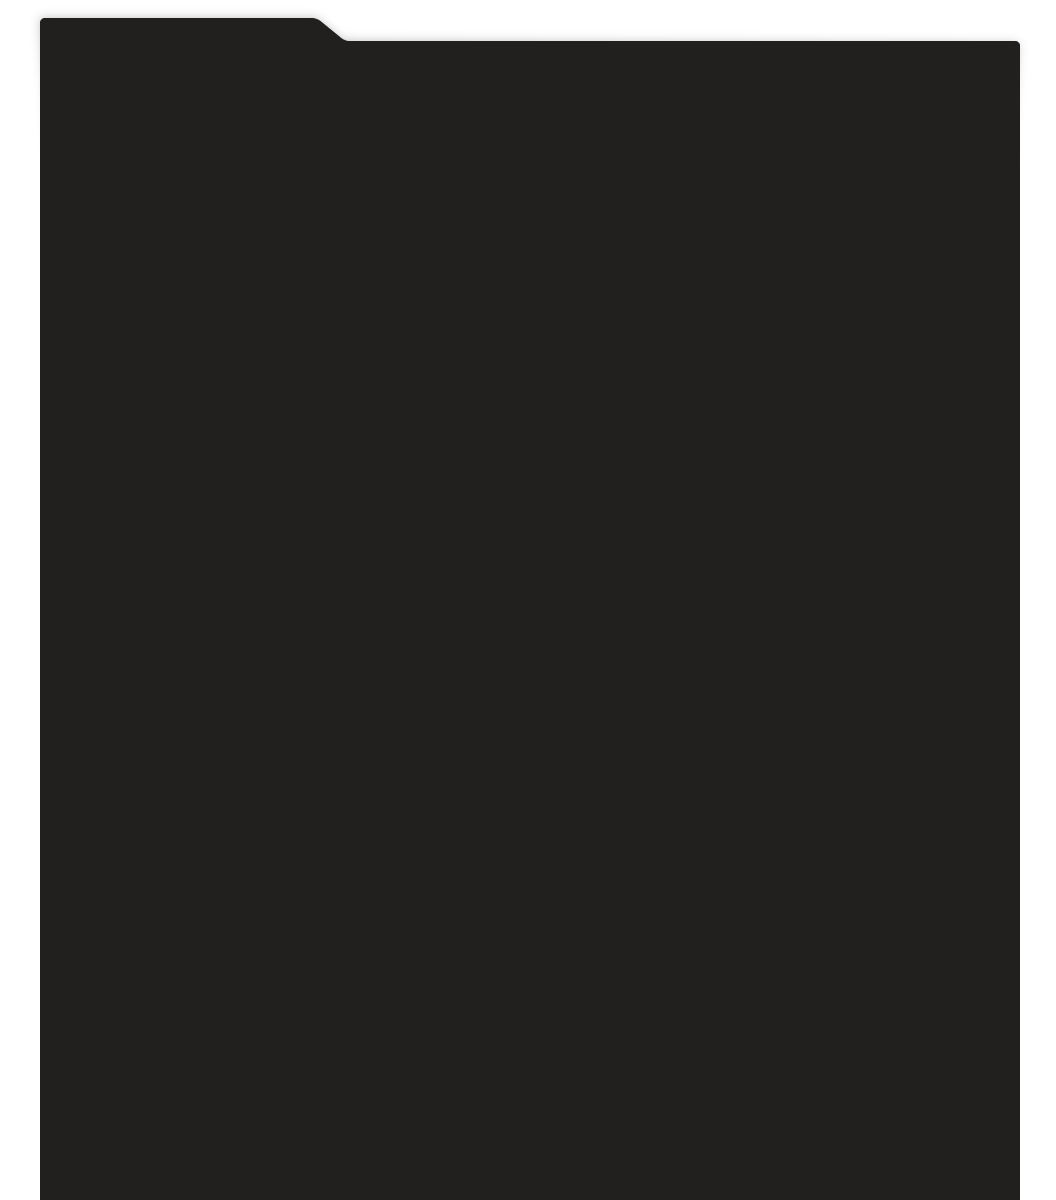
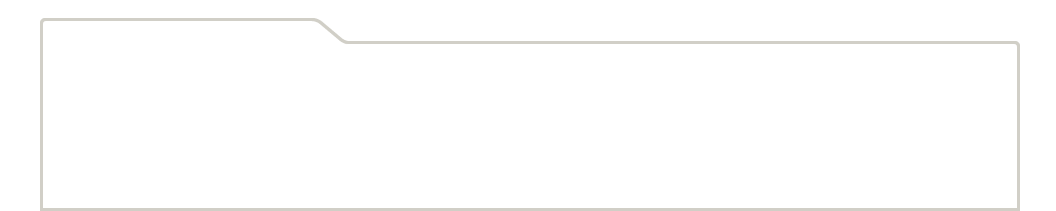
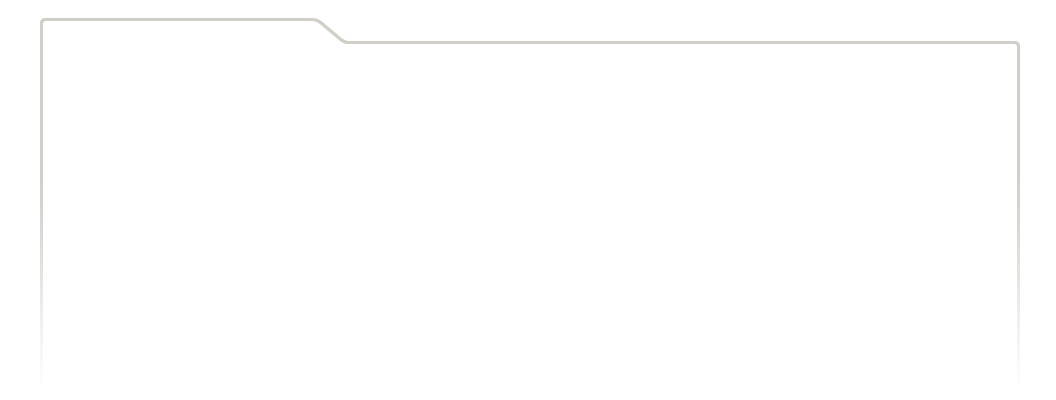
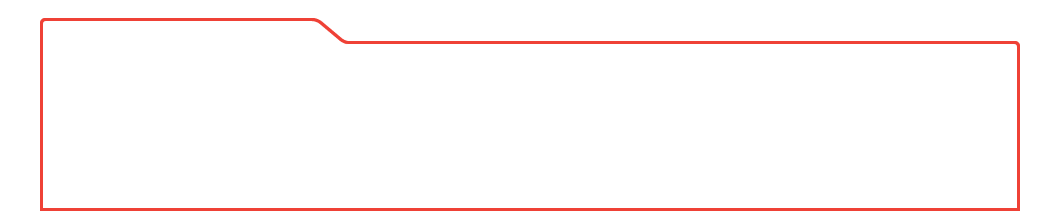
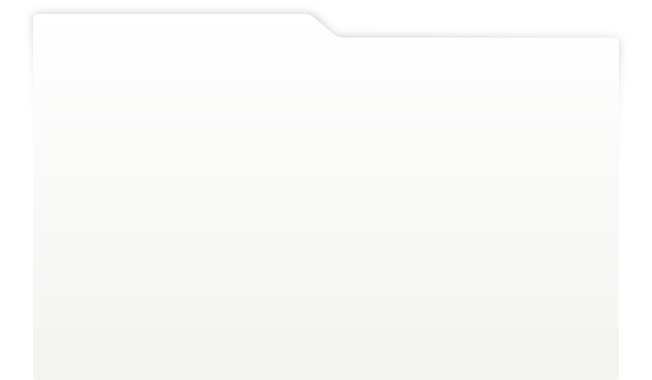
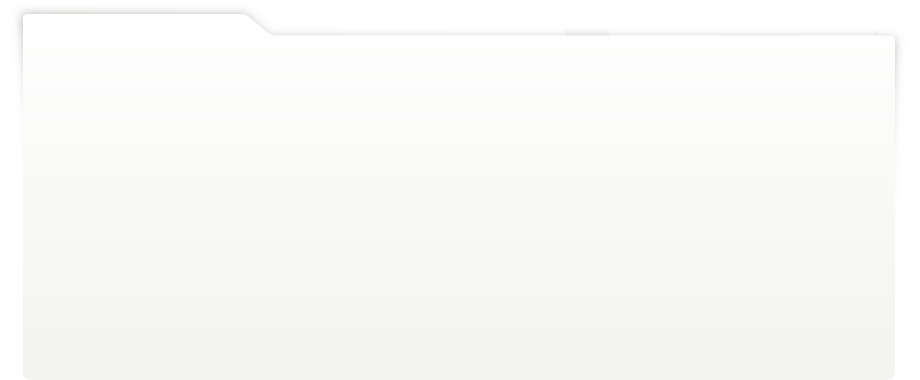
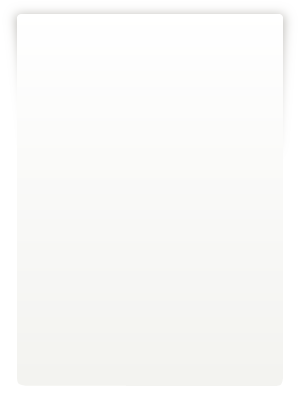
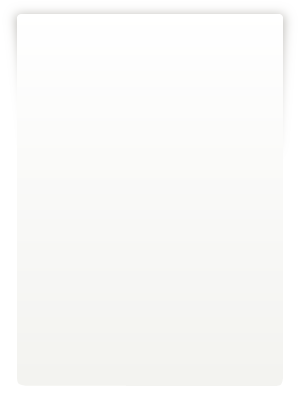
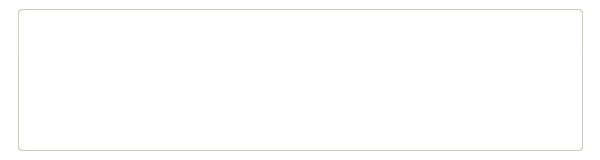
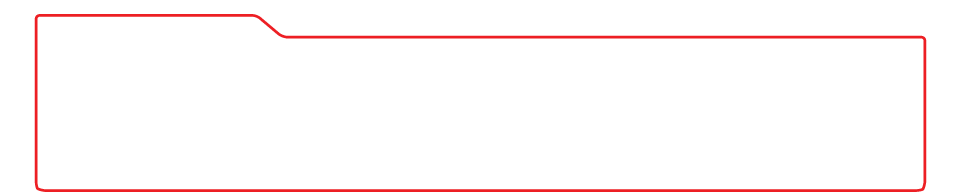
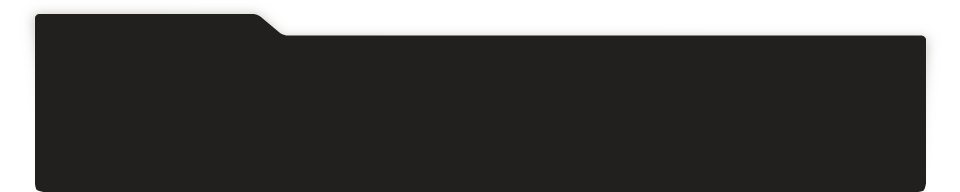
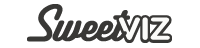
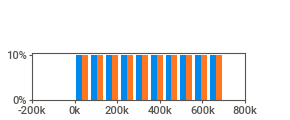
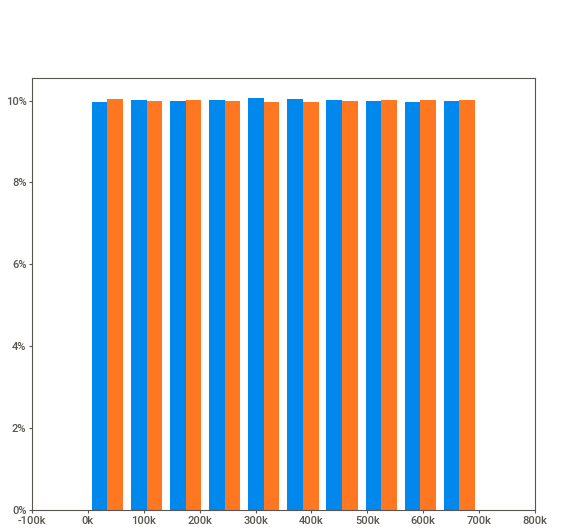
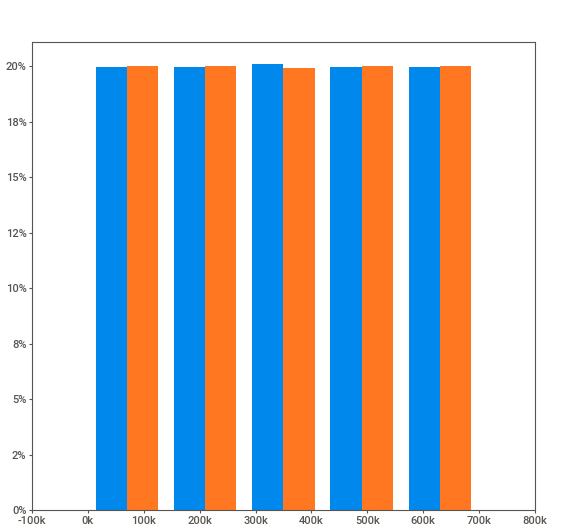
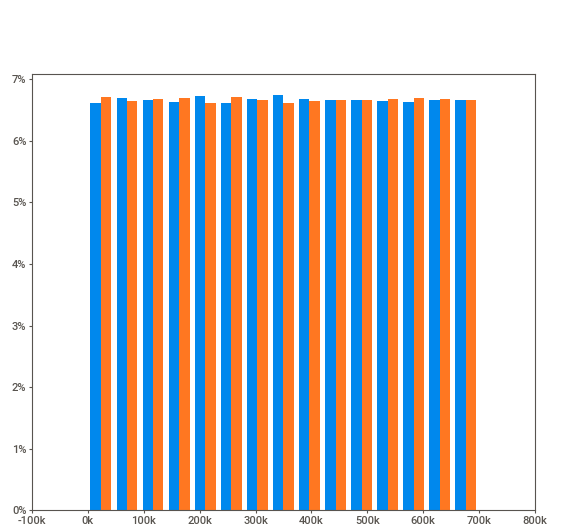
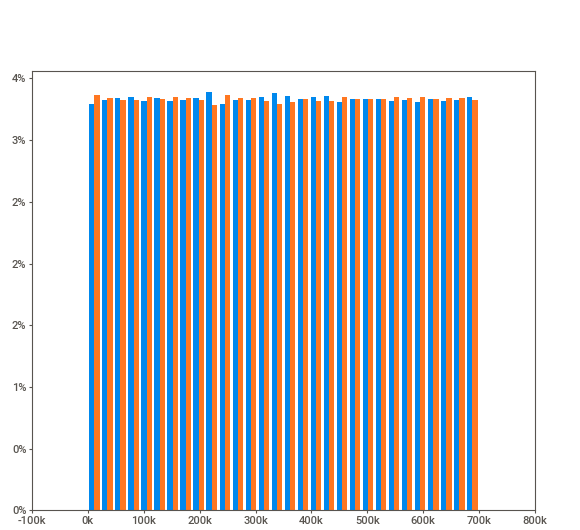
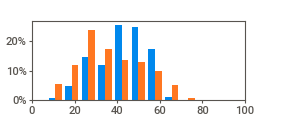
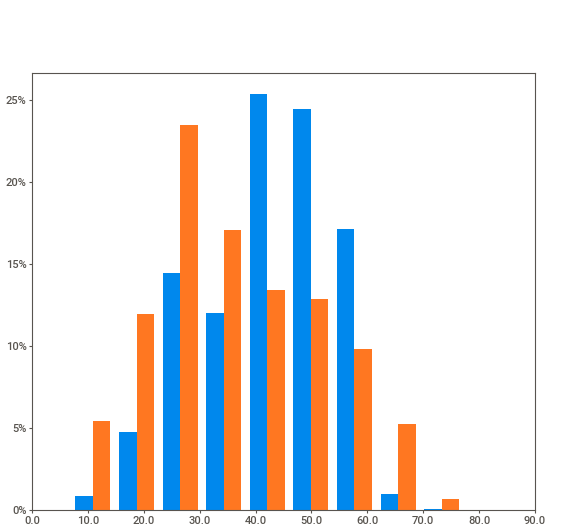
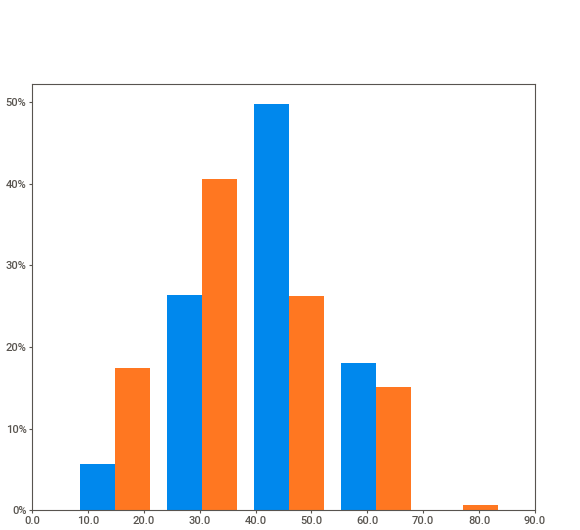
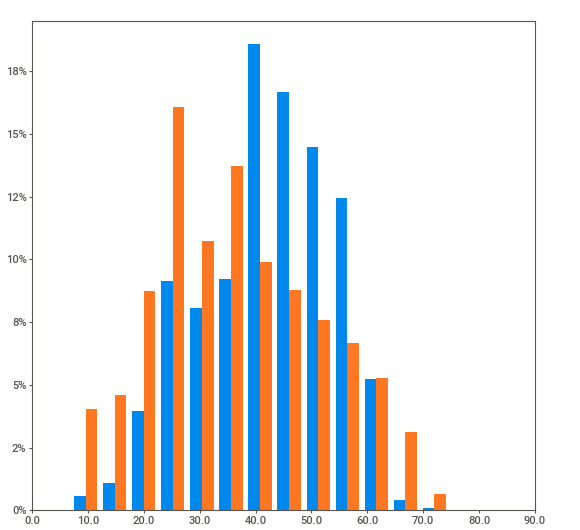
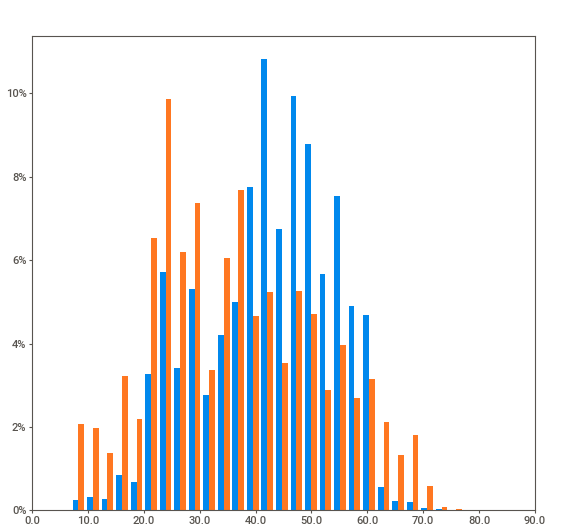
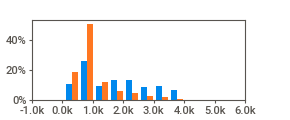
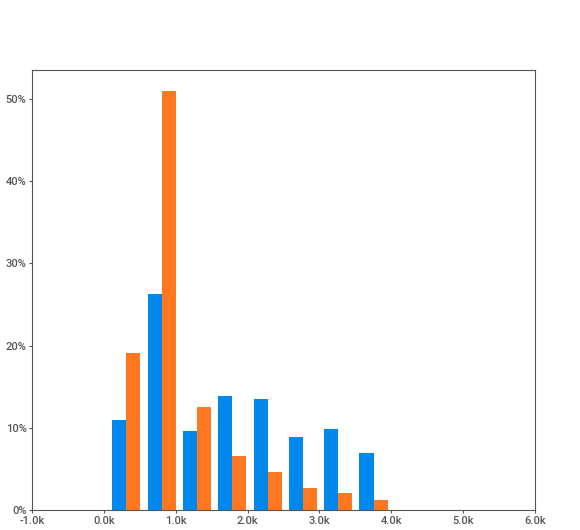
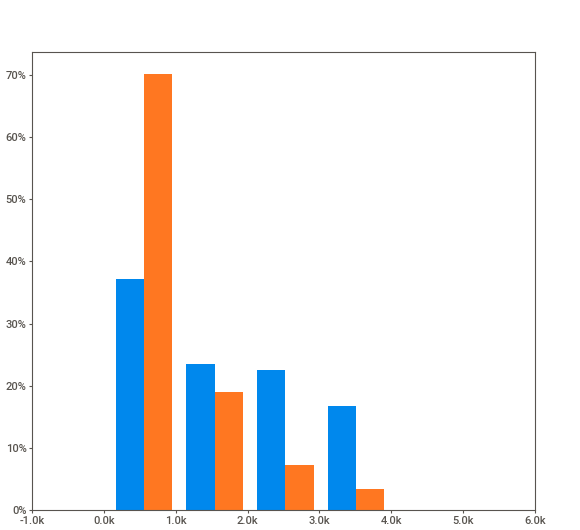
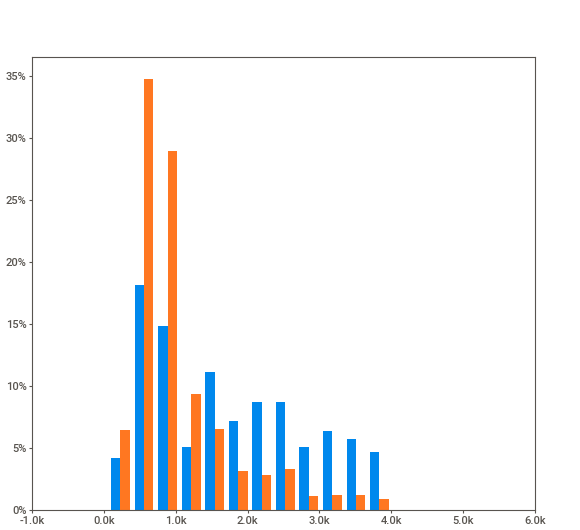
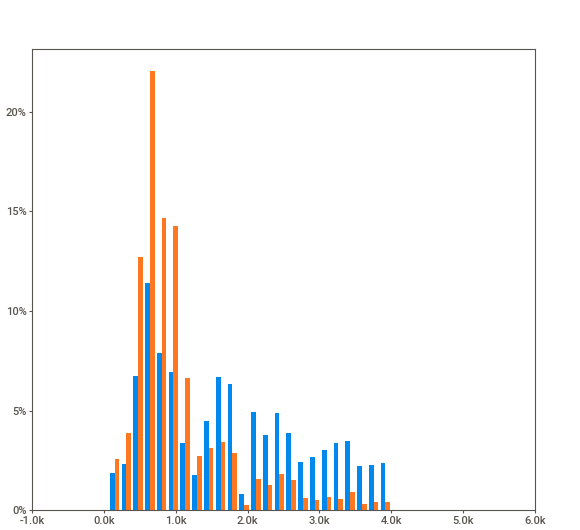
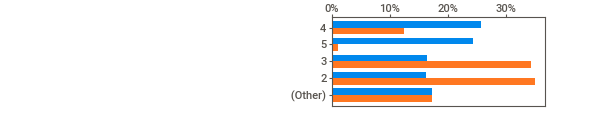
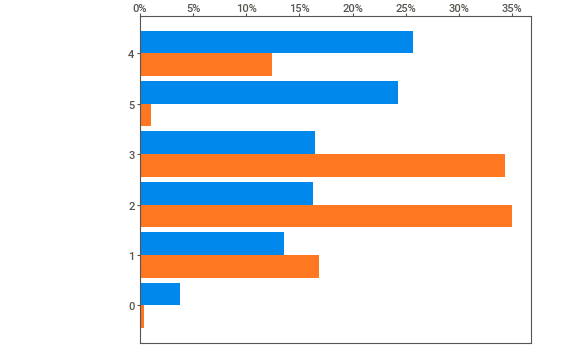
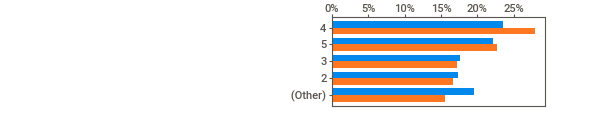
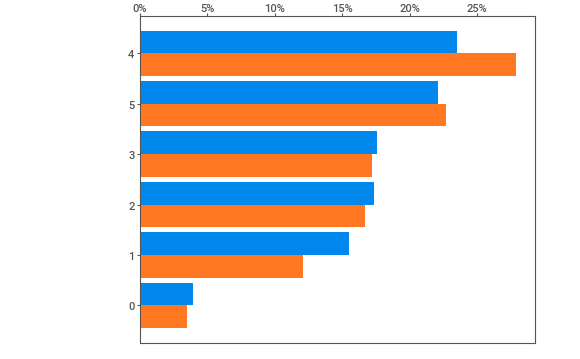
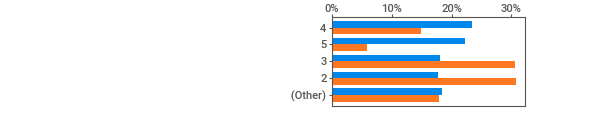
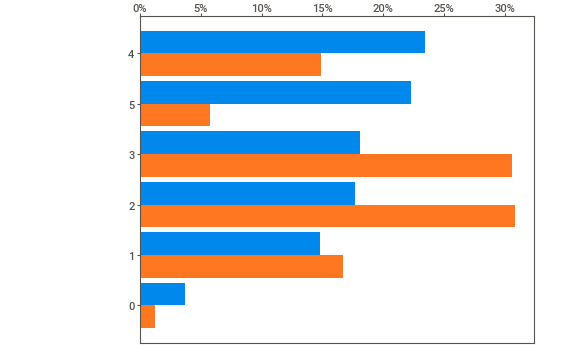
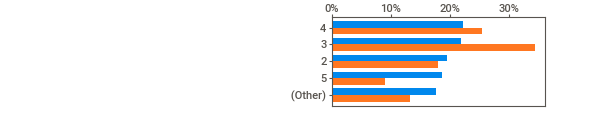
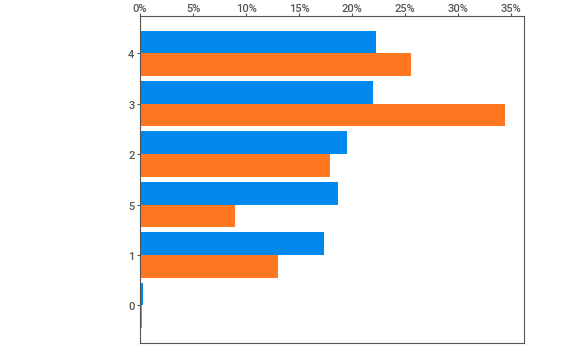
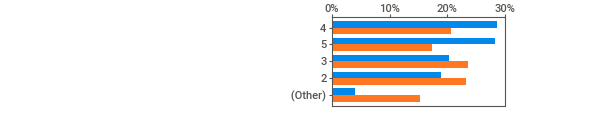
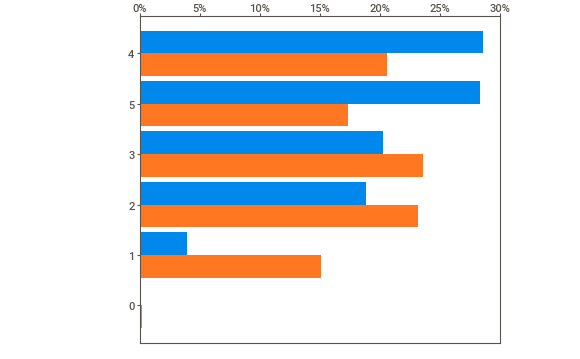
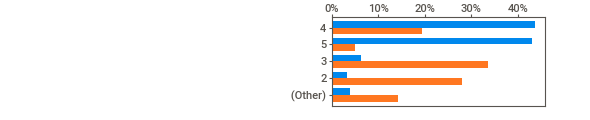
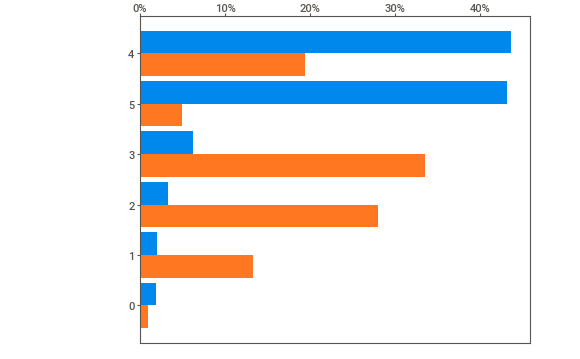
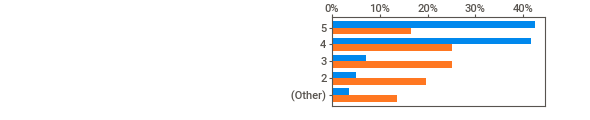
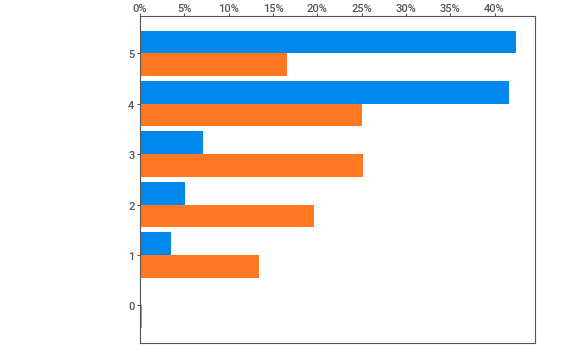
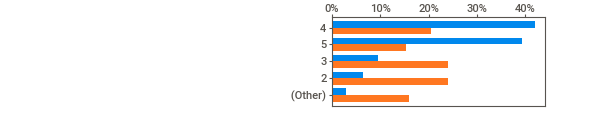
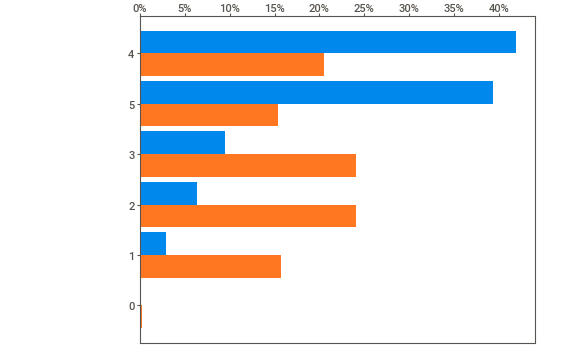
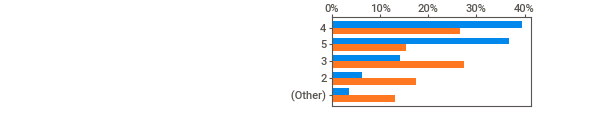
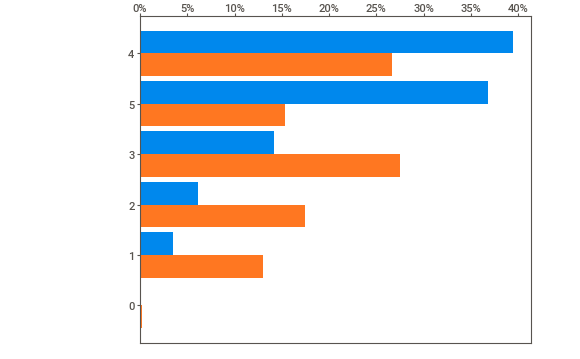
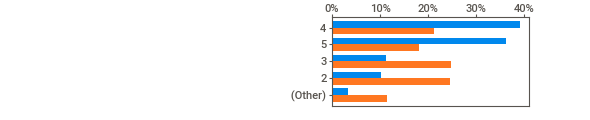
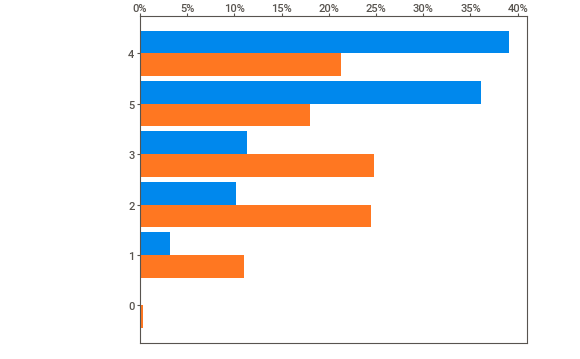
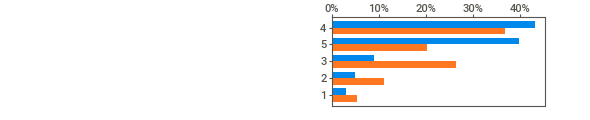
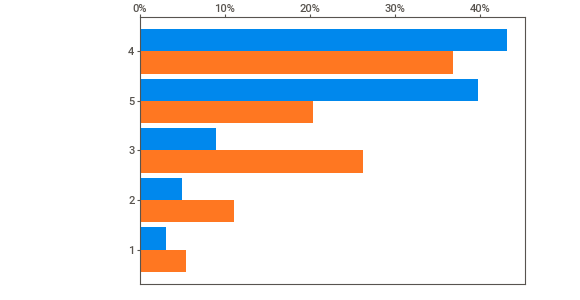
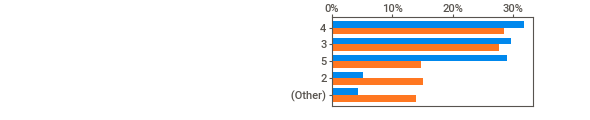
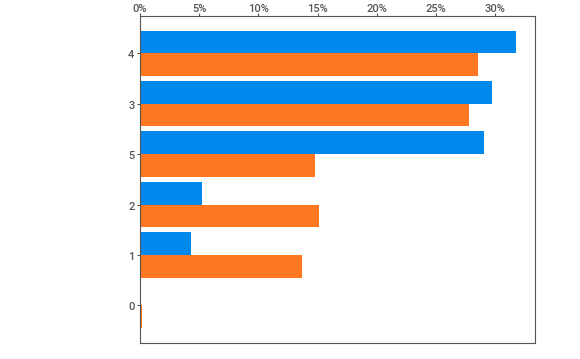
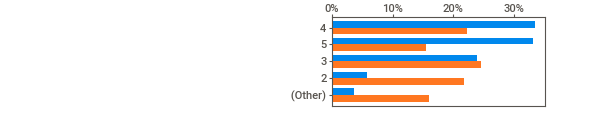
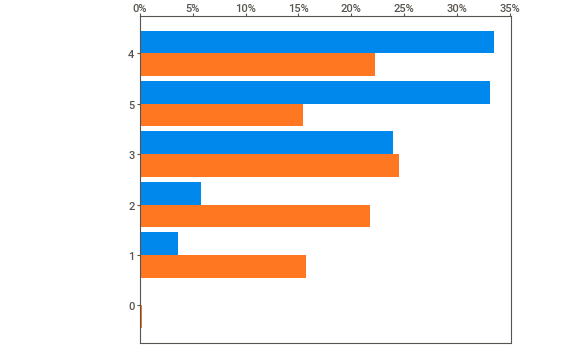
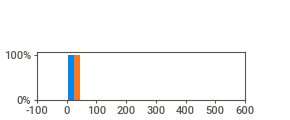
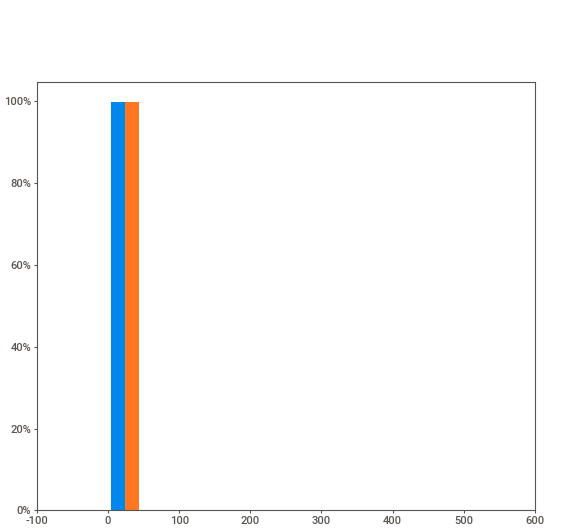
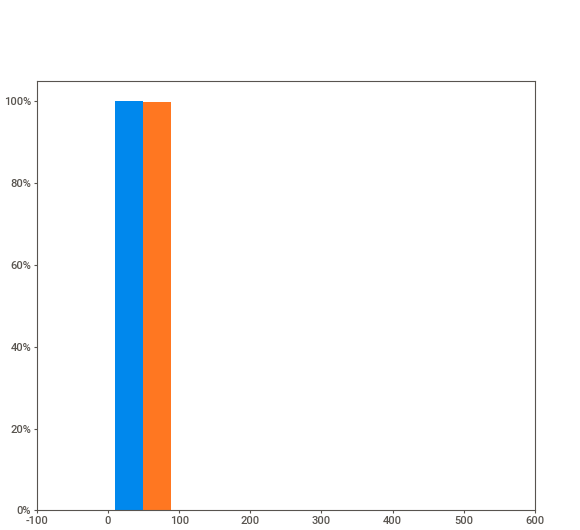
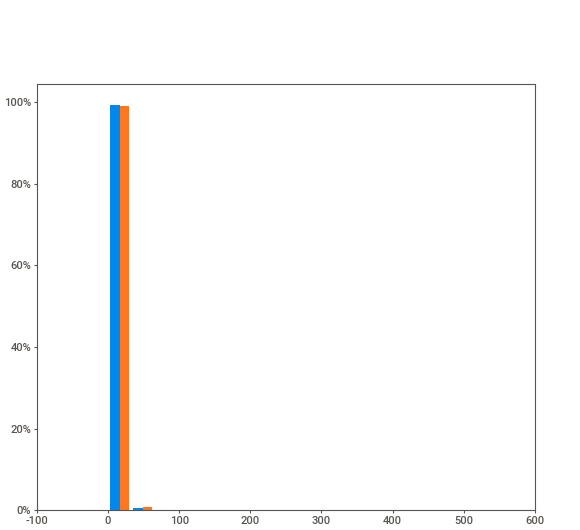
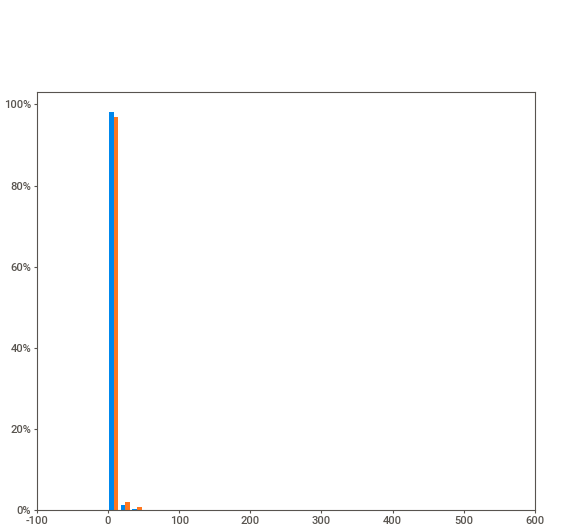
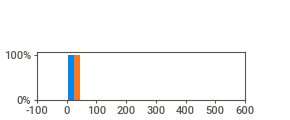
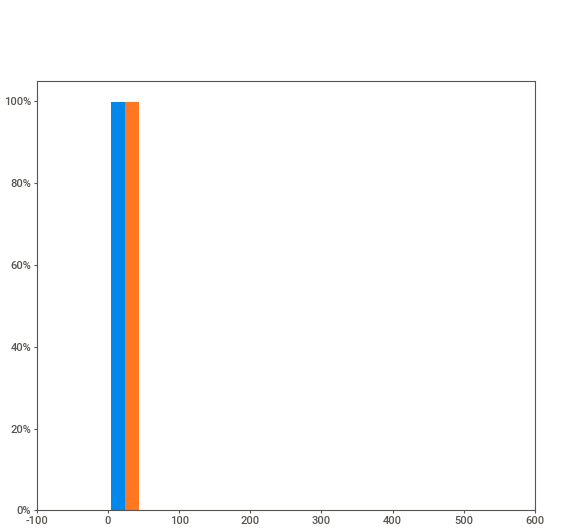
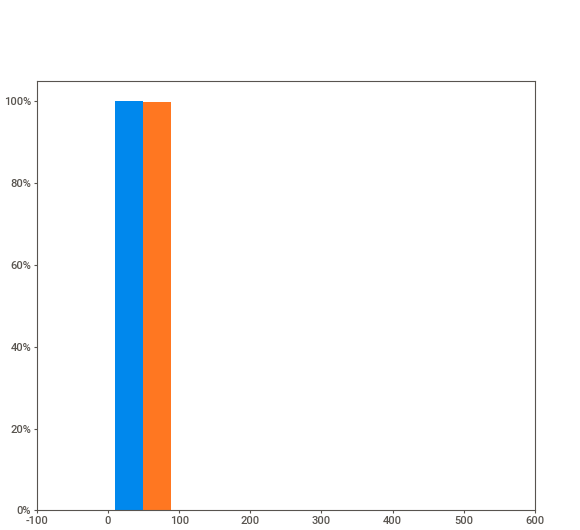
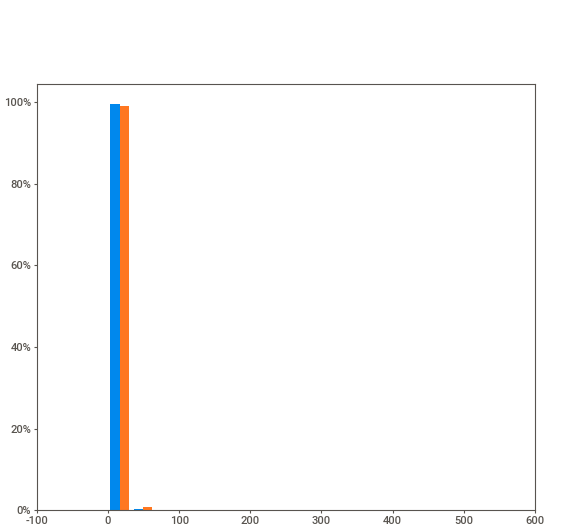
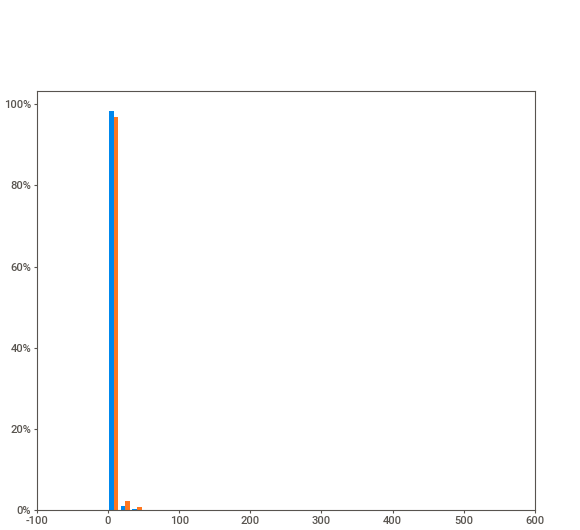
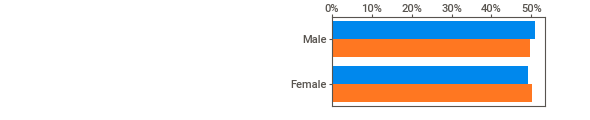
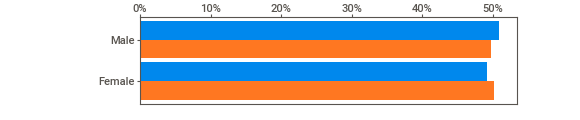
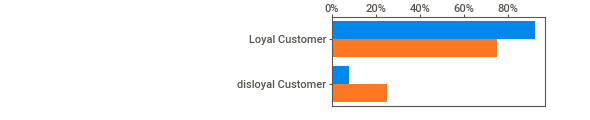
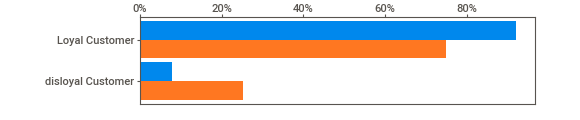
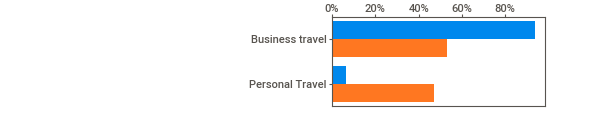
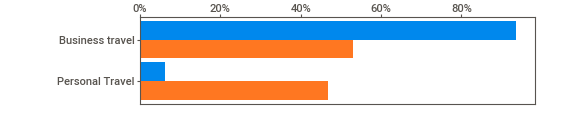
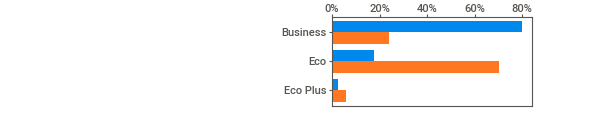
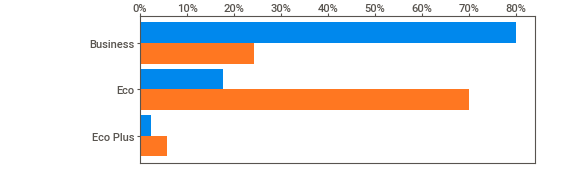
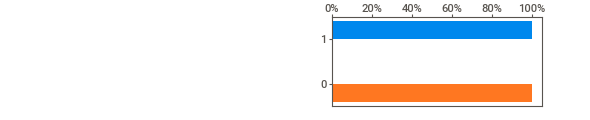
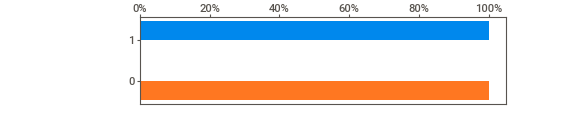
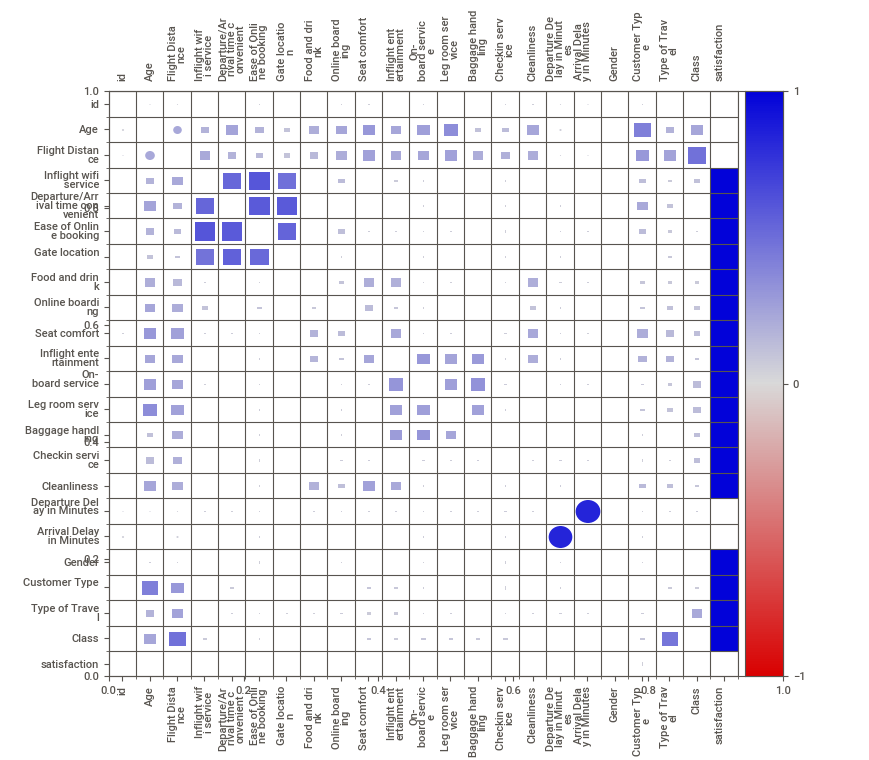
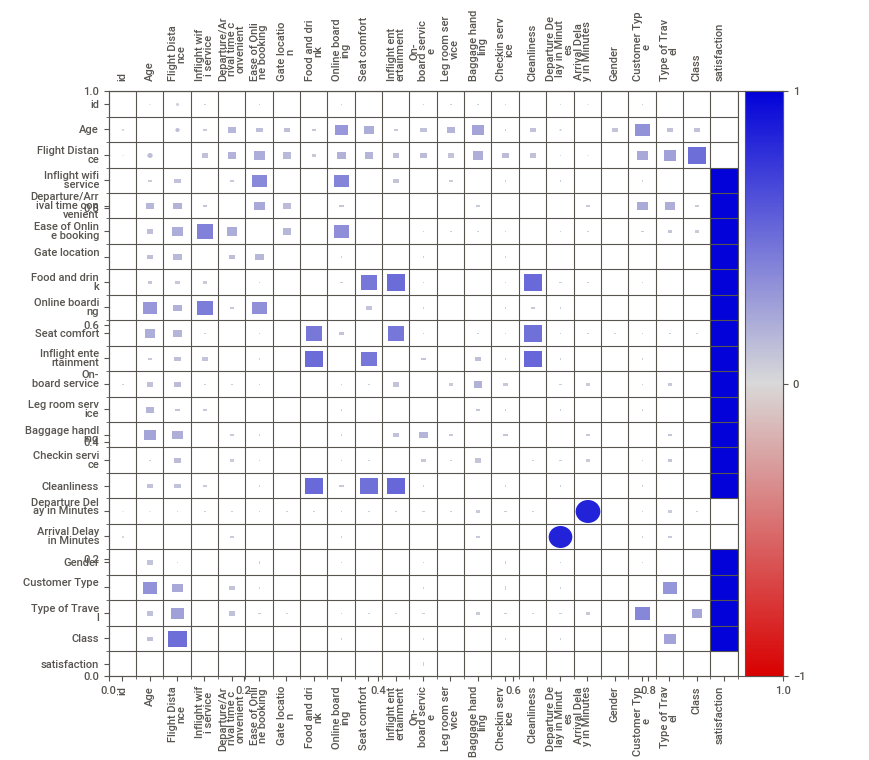

In [8]:
satisfied_vs_others_report = sv.compare_intra(
    sweetviz_train_df,
    sweetviz_train_df[TARGET] == 1,
    ["Satisfied", "Neutral / Dissatisfied"],
    target_feat=None
)

# Save HTML report file
satisfied_vs_others_report.show_html(
    filepath="sweetviz_satisfied_intra.html",
    open_browser=False
)

# Render in notebook
satisfied_vs_others_report.show_notebook(
    w="100%",
    h=1000,
    scale=0.85
)

## 4. Custom Visualizations (DataVisualizer)

Run our target-aware visualization suite to extract top signals, target trends, and categorical relationships.

Using XKCD style


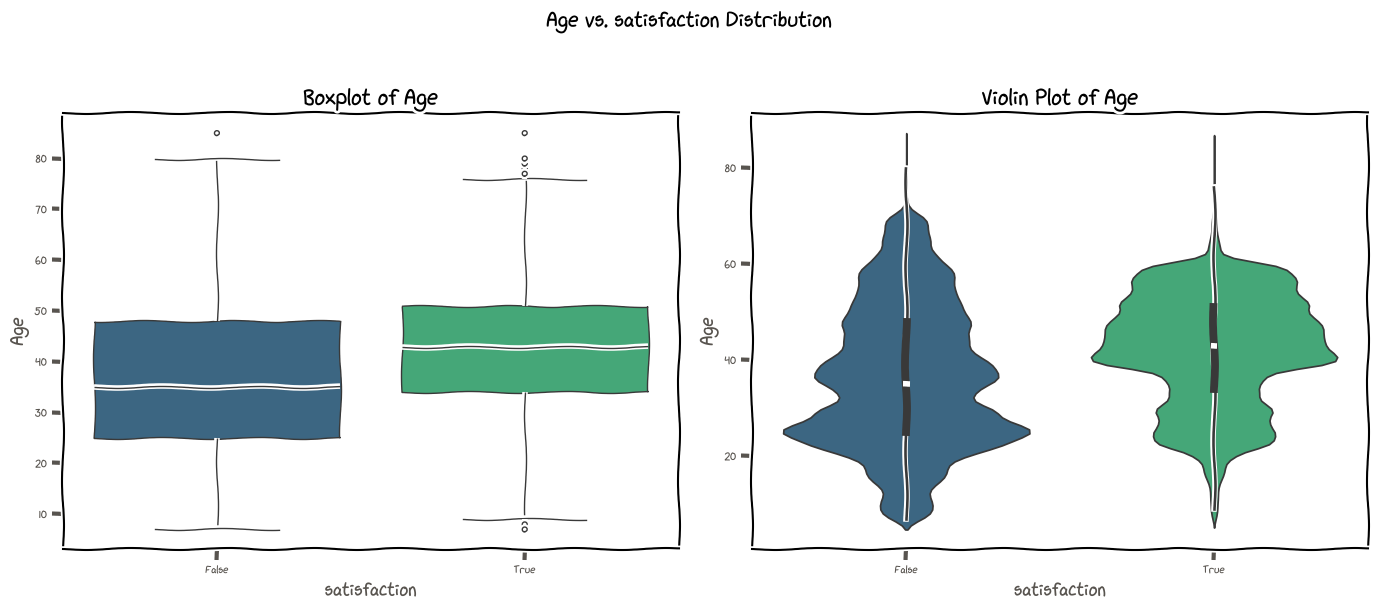

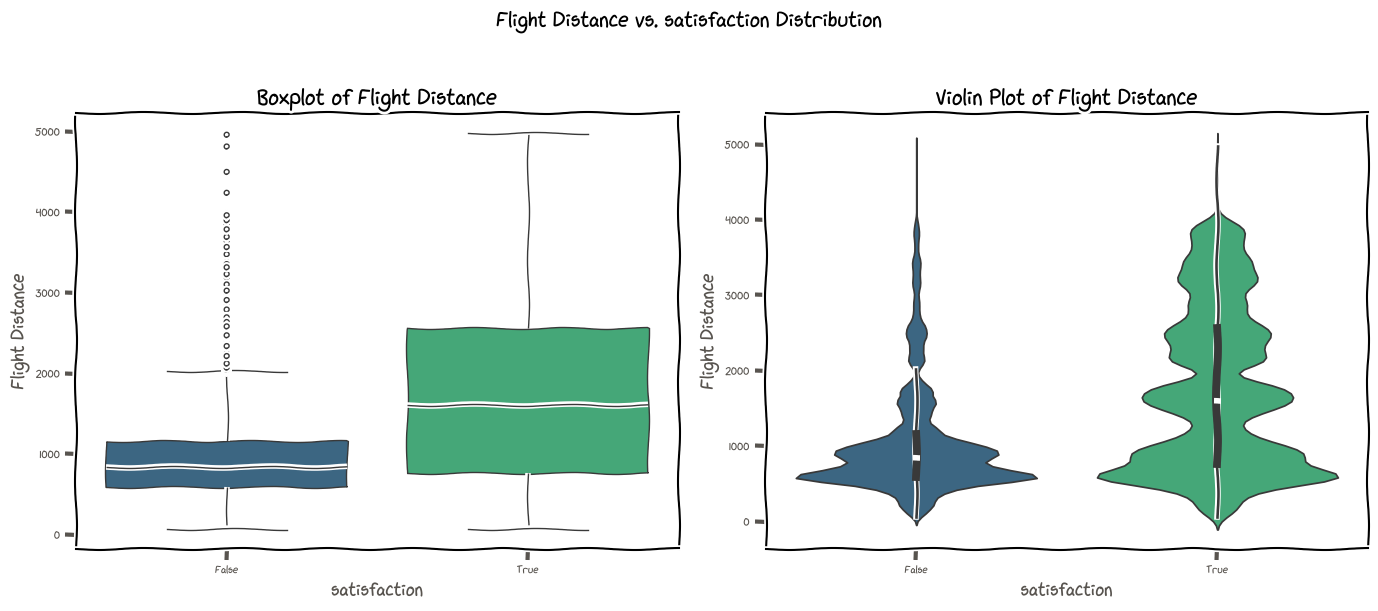

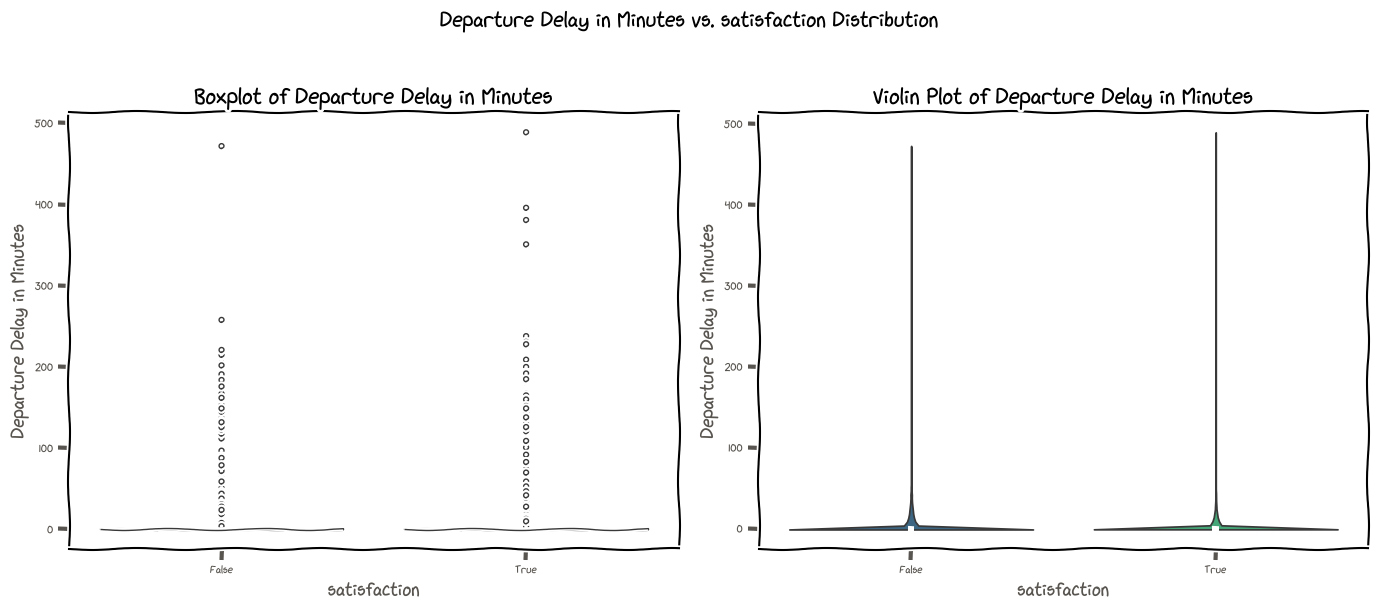

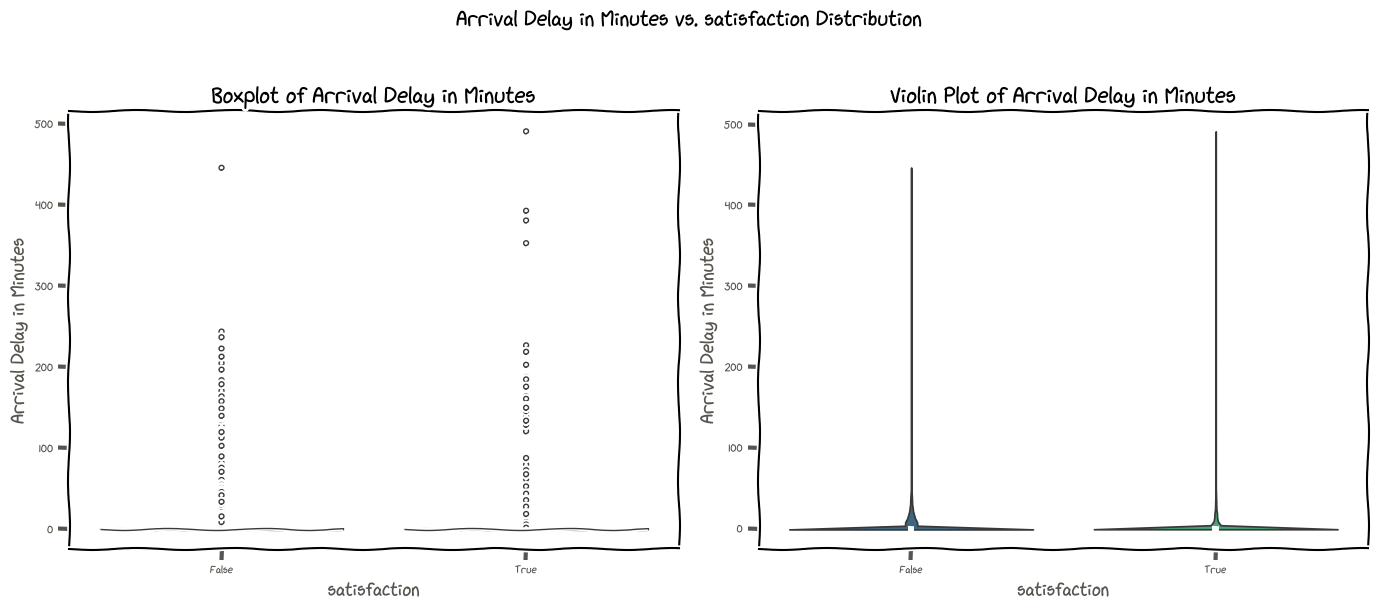

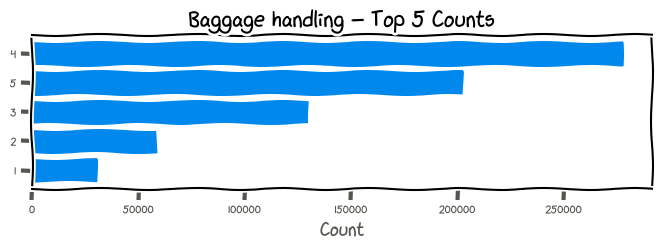

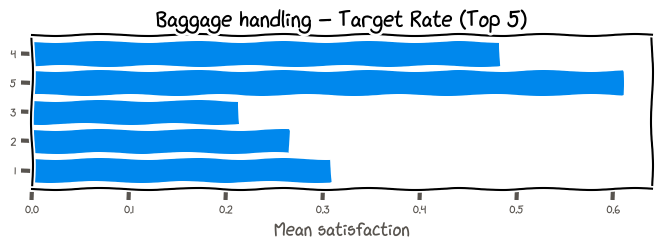

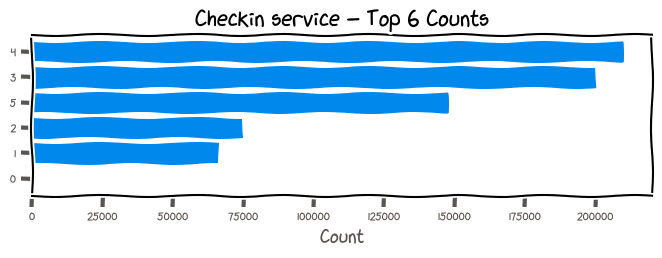

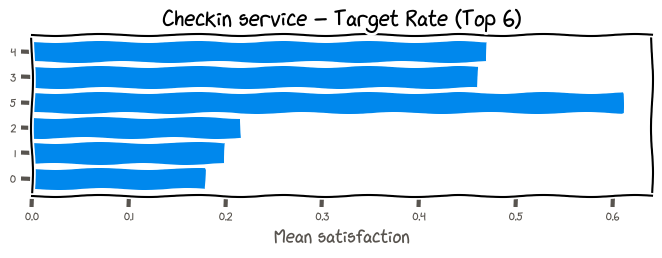

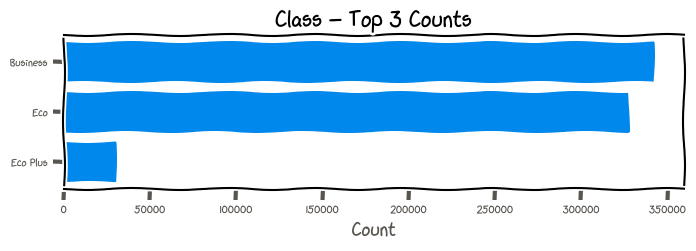

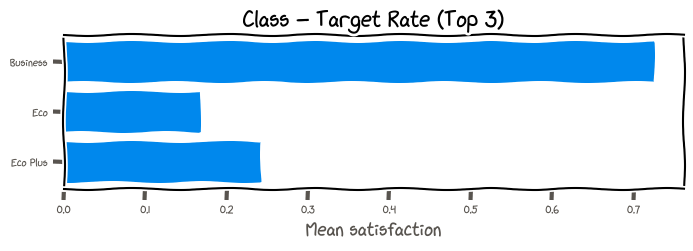

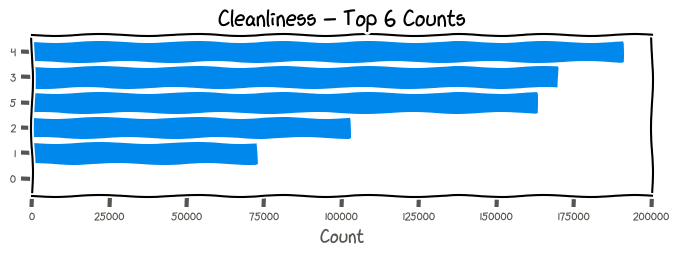

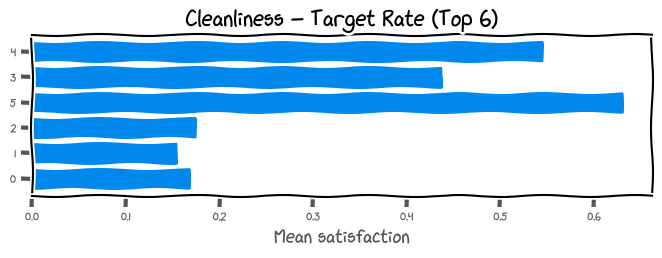

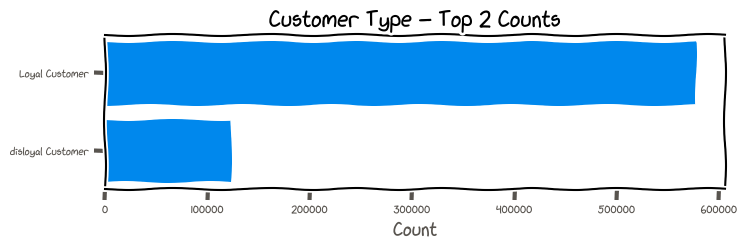

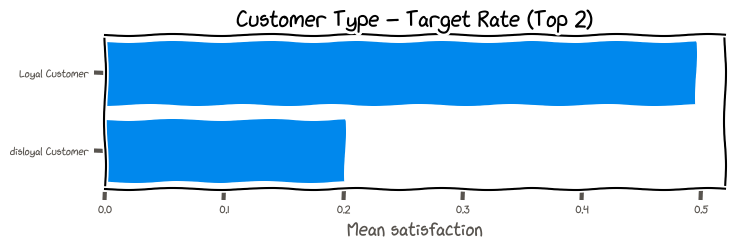

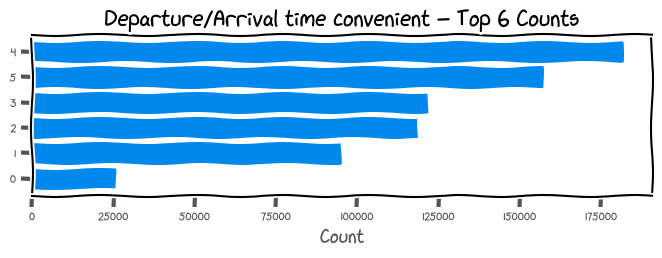

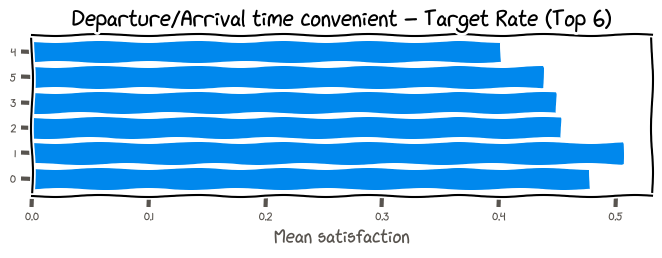

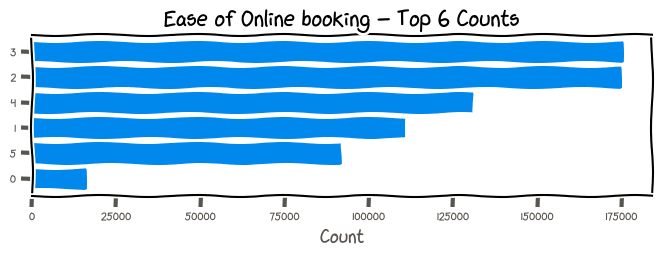

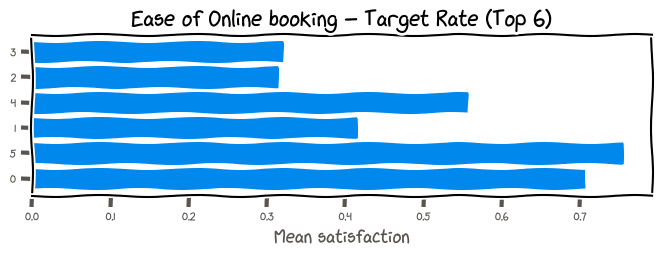

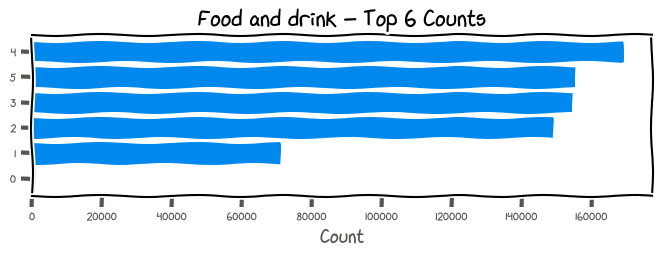

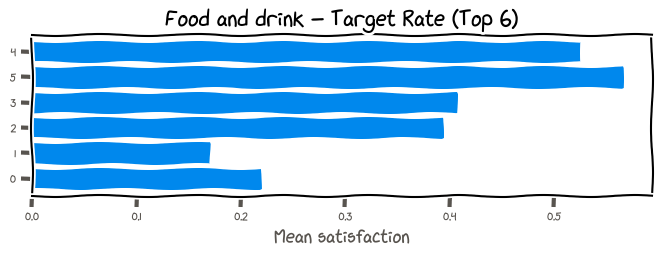

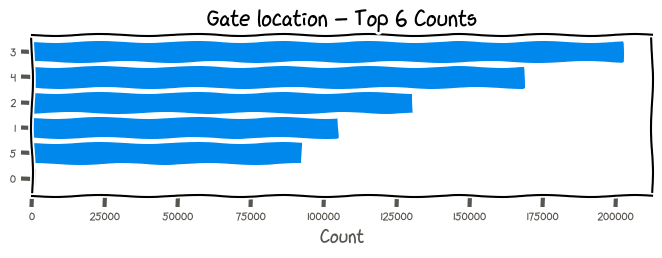

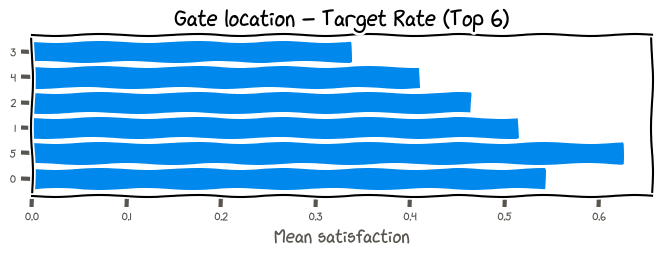

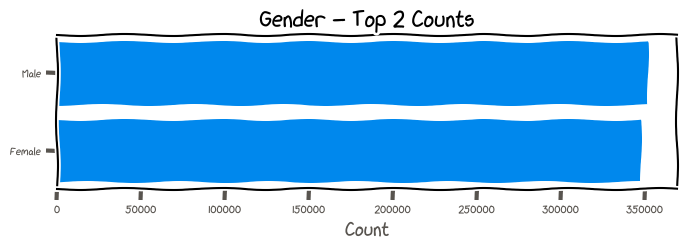

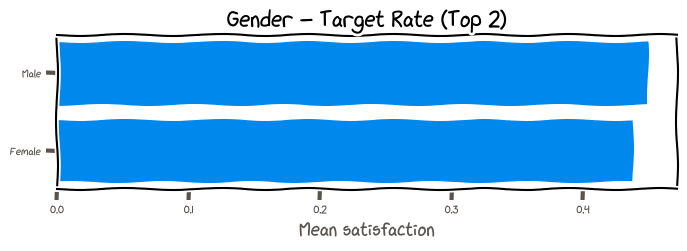

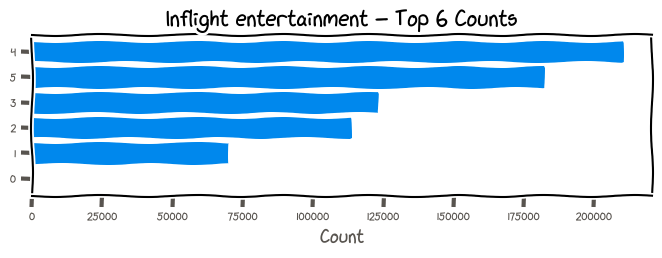

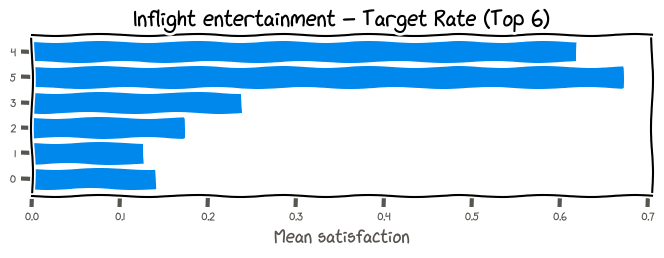

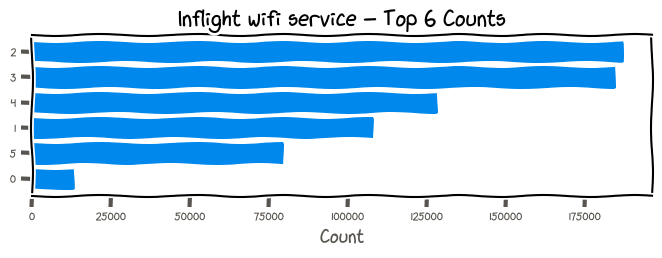

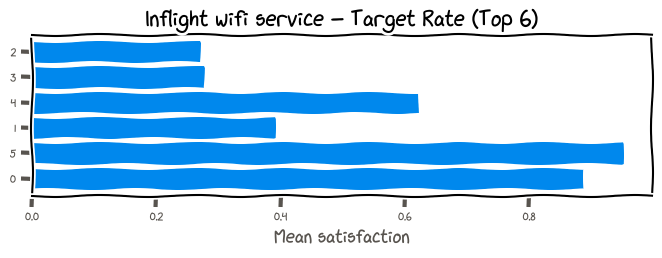

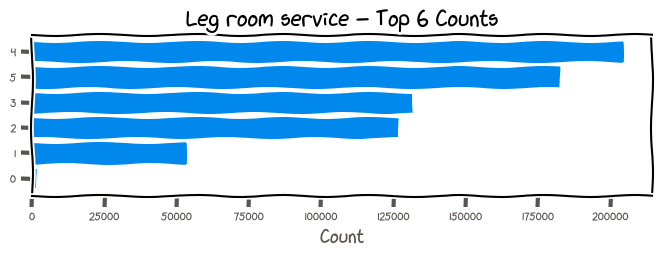

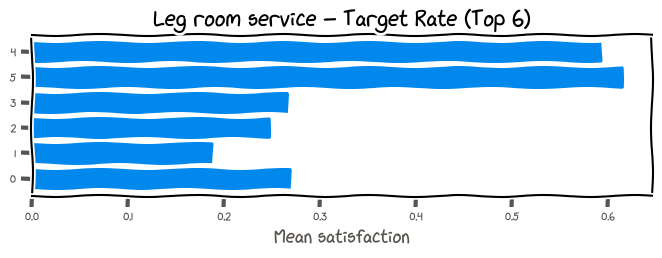

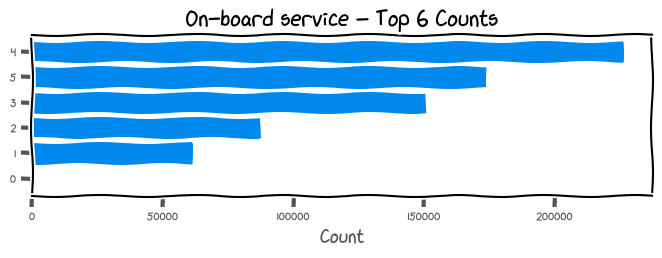

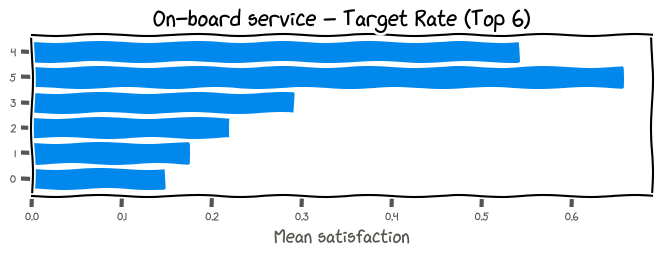

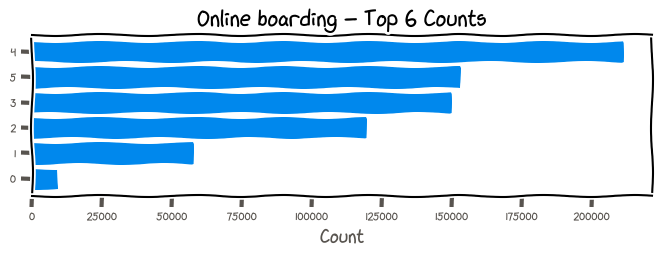

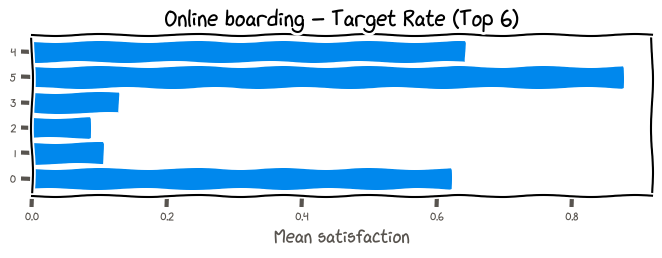

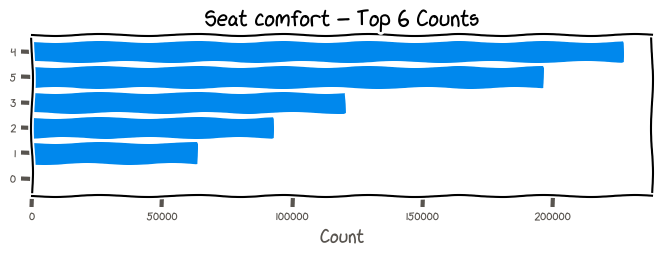

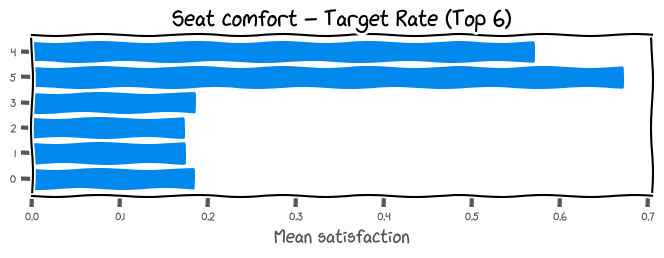

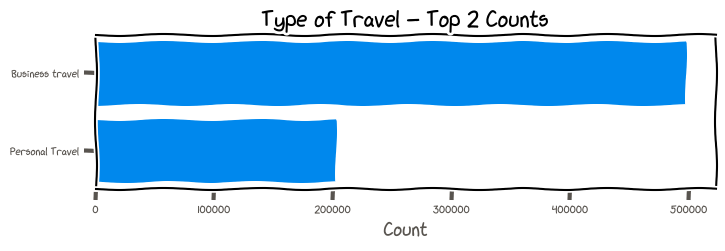

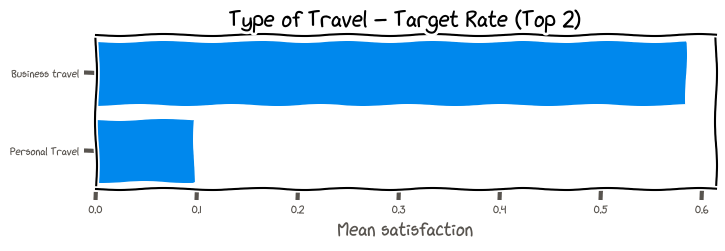

### Numeric x Category Trend

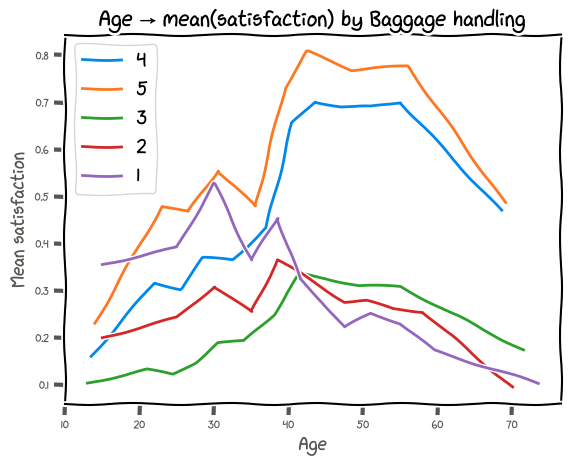

### Category x Category Trend

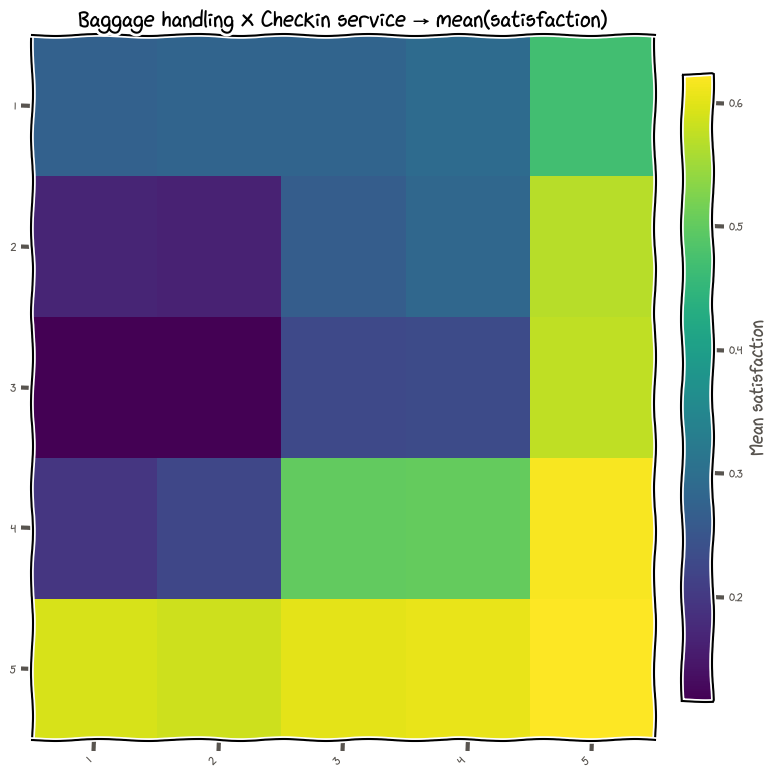

### Feature Signal Ranking

Top numeric (|Spearman|): [('Online boarding', 0.6020394719548418), ('Inflight entertainment', 0.4329916309152938), ('Seat comfort', 0.41296190408470074), ('On-board service', 0.3541326445641629), ('Flight Distance', 0.3366012480791487), ('Cleanliness', 0.33465238593621666), ('Leg room service', 0.3323939549282785), ('Inflight wifi service', 0.2870080781613876), ('Baggage handling', 0.2800678778387174), ('Checkin service', 0.24079450636648927)]
Top categorical (range of mean target): [('Class', 0.5577531131195698, 3), ('Type of Travel', 0.48707361027748547, 2), ('Customer Type', 0.29419967722136886, 2), ('Gender', 0.011097616854215009, 2)]


In [9]:
setup.use_xkcd_style()

visualizer = DataVisualizer(target=TARGET, seed=setup.primary_seed())
visualizer.run_data_visualization(training_df)

### Correlation and Feature Signal Insights

1. **Dominant Rating Signals**:
   * `Online boarding` & `Inflight wifi service`: Strongest linear and non-linear rating predictors for passenger satisfaction.
   * `Inflight entertainment`, `Seat comfort`, `On-board service`, `Leg room service`, and `Cleanliness`: High positive correlation with satisfaction.

2. **Categorical Drivers**:
   * `Type of Travel`: Passengers traveling for **Business** report significantly higher satisfaction than those on **Personal Travel**.
   * `Class`: **Business Class** passengers exhibit substantially higher satisfaction rates compared to **Eco** and **Eco Plus**.
   * `Customer Type`: **Loyal Customers** show consistently higher satisfaction than **disloyal Customers**.

3. **Key Interaction Opportunities**:
   * Interaction between `Class` and `Type of Travel` (Business travel in Business class creates a distinct high-satisfaction segment).
   * Interaction between delays (`Departure Delay in Minutes` vs `Arrival Delay in Minutes`) and rating services.

## 5. Visualizing Numerical Feature Distributions (Train vs Test)

Overlays KDE plots to visually confirm distribution matching across splits.

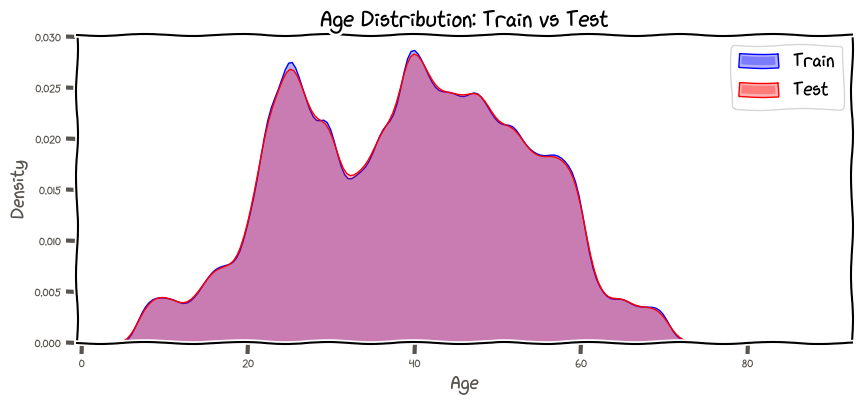

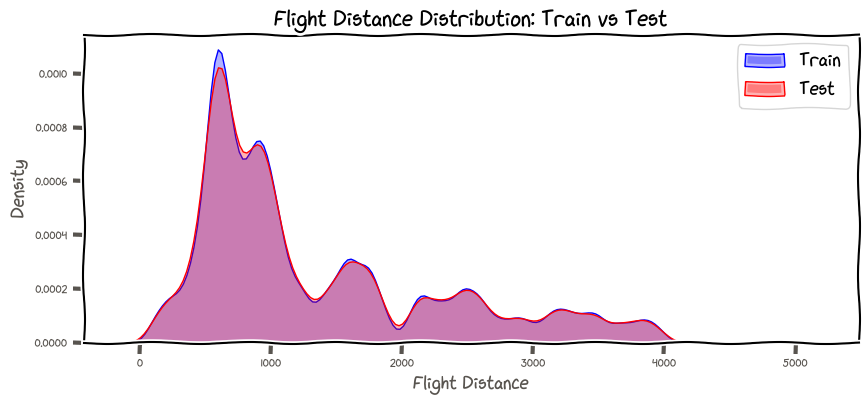

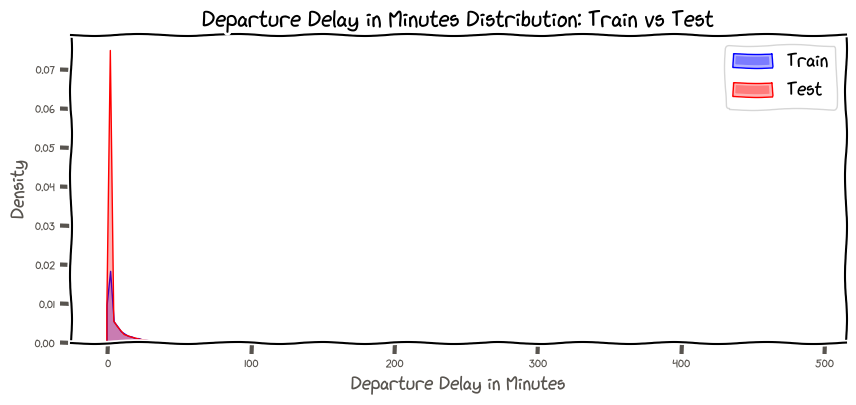

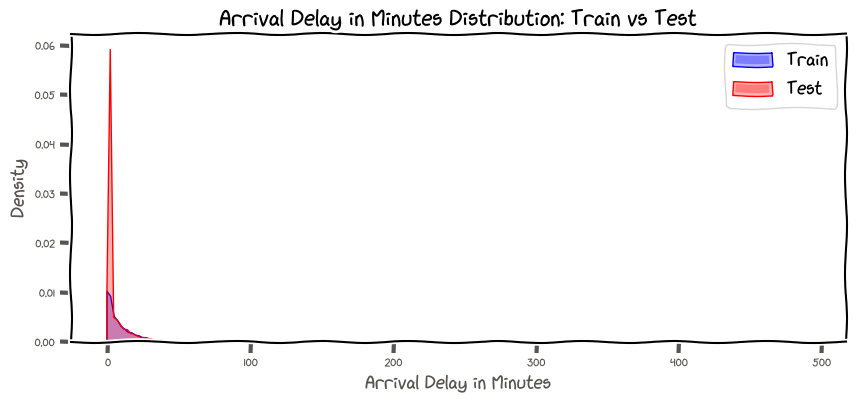

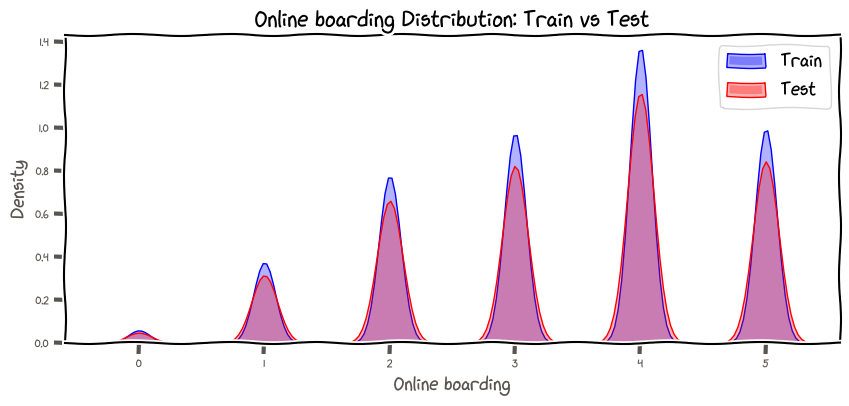

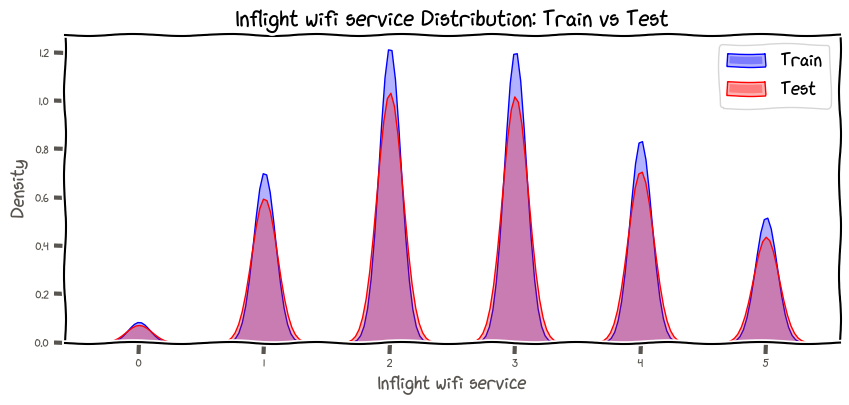

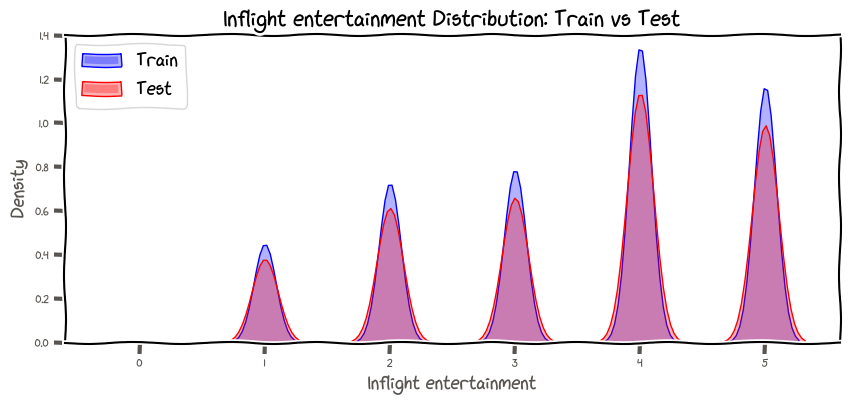

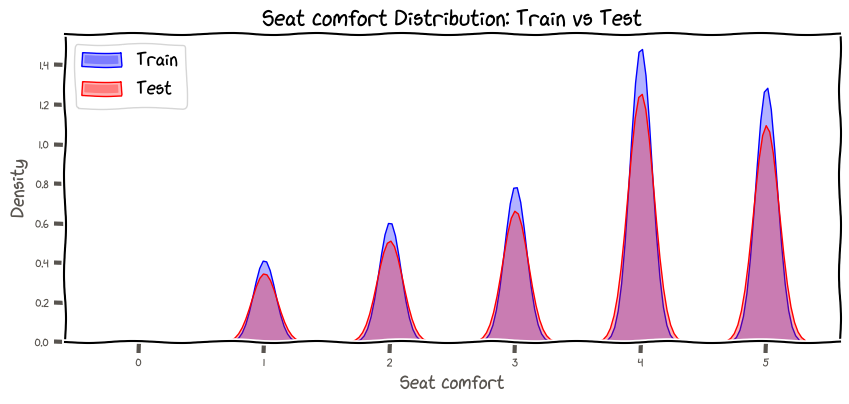

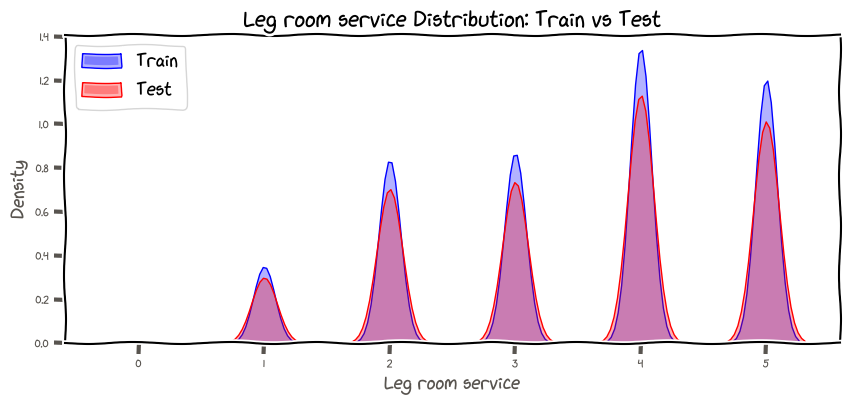

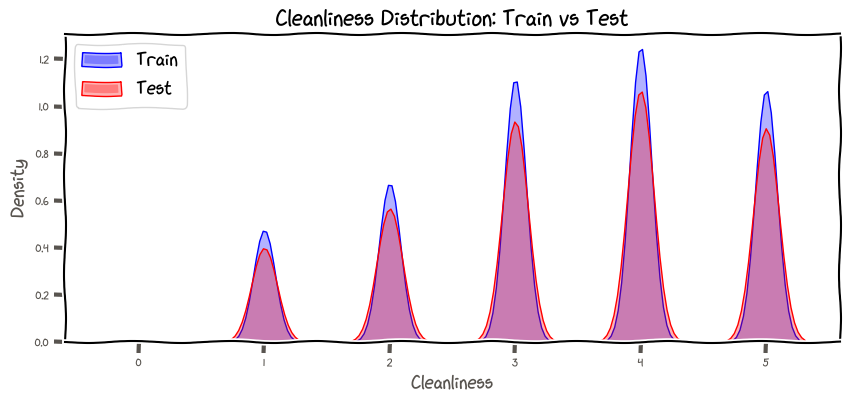

In [10]:
tops = [
    'Age',
    'Flight Distance',
    'Departure Delay in Minutes',
    'Arrival Delay in Minutes',
    'Online boarding',
    'Inflight wifi service',
    'Inflight entertainment',
    'Seat comfort',
    'Leg room service',
    'Cleanliness'
]
for top in tops:
    if top in training_df.columns and top in test_df.columns:
        plt.figure(figsize=(10, 4))
        sns.kdeplot(training_df[top].dropna(), label='Train', fill=True, color='blue', alpha=0.3)
        sns.kdeplot(test_df[top].dropna(), label='Test', fill=True, color='red', alpha=0.3)
        plt.title(f'{top} Distribution: Train vs Test')
        plt.xlabel(top)
        plt.ylabel('Density')
        plt.legend()
        plt.show()